
 ## Project Objective

The objective of this project is to perform Exploratory Data Analysis (EDA) on retail sales data to understand customer behavior, sales patterns, product performance, discounts, payments, shipping, ratings, and returns.

The project focuses on:
- Data inspection
- Data cleaning
- Missing-value handling
- Feature engineering
- Exploratory analysis
- Data visualization
- Correlation analysis
- Outlier detection and treatment
- Business insights

In [2]:
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("retail.csv", encoding="latin1")


In [4]:
df.head()

,OrderID,OrderDate,CustomerName,CustomerAge,Gender,CustomerCity,ProductCategory,ProductName,Quantity,UnitPrice,DiscountPercent,DeliveryDays,PaymentMethod,CustomerRating,ShippingCost,CouponCode,ReturnReason
0,ORD100674,2024-07-20,Diya Verma,34.0,m,Delhi,Beauty & Personal Care,Lip Balm Pack,4.0,144.70,0.0,4.0,Net Banking,4.0,0.0,NaN,NaN
1,ORD102063,2024-10-17,Reyansh Sharma,31.0,M,Kolkata,Footwear,Formal Leather Shoes,2.0,486.07,40.0,2.0,Debit Card,NaN,0.0,NEWUSER15,NaN
2,ORD100377,2024-11-11,Sara Deshmukh,51.0,Male,Pune,Apparel,Men Cotton T-Shirt,1.0,852.46,10.0,3.0,Credit Card,4.0,NaN,FEST20,NaN
3,ORD100802,2024-04-14,Riya Kapoor,49.0,NaN,Nagpur,Apparel,Men Cotton T-Shirt,1.0,1246.09,0.0,2.0,NaN,NaN,NaN,NEWUSER15,NaN
4,ORD101208,2023-09-17,Sneha Pillai,39.0,M,Lucknow,Grocery,Green Tea Pack,1.0,379.31,25.0,4.0,Debit Card,NaN,80.0,FLAT100,NaN


# initial inspection

In [5]:
df.shape

(3060, 17)

In [6]:
df.columns

Index(['OrderID', 'OrderDate', 'CustomerName', 'CustomerAge', 'Gender',
       'CustomerCity', 'ProductCategory', 'ProductName', 'Quantity',
       'UnitPrice', 'DiscountPercent', 'DeliveryDays', 'PaymentMethod',
       'CustomerRating', 'ShippingCost', 'CouponCode', 'ReturnReason'],
      dtype='object')

In [7]:
df.describe()

,CustomerAge,Quantity,UnitPrice,DiscountPercent,DeliveryDays,CustomerRating,ShippingCost
count,2969.000000,3060.000000,2982.000000,3060.000000,3060.000000,2200.000000,1992.000000
mean,34.638599,2.838235,999.326486,12.970588,5.846405,3.842273,52.259036
std,12.028286,10.545763,1037.875697,12.757929,4.674701,1.163776,46.463232
min,0.000000,-5.000000,80.350000,-25.000000,-3.000000,1.000000,0.000000
25%,28.000000,1.000000,478.497500,5.000000,4.000000,3.000000,0.000000
50%,34.000000,2.000000,785.930000,10.000000,5.000000,4.000000,60.000000
75%,41.000000,3.000000,1331.112500,20.000000,8.000000,5.000000,80.000000
max,150.000000,200.000000,20819.867889,150.000000,60.000000,5.000000,150.000000


In [8]:
df.head(2)

,OrderID,OrderDate,CustomerName,CustomerAge,Gender,CustomerCity,ProductCategory,ProductName,Quantity,UnitPrice,DiscountPercent,DeliveryDays,PaymentMethod,CustomerRating,ShippingCost,CouponCode,ReturnReason
0,ORD100674,2024-07-20,Diya Verma,34.0,m,Delhi,Beauty & Personal Care,Lip Balm Pack,4.0,144.70,0.0,4.0,Net Banking,4.0,0.0,NaN,NaN
1,ORD102063,2024-10-17,Reyansh Sharma,31.0,M,Kolkata,Footwear,Formal Leather Shoes,2.0,486.07,40.0,2.0,Debit Card,NaN,0.0,NEWUSER15,NaN


In [9]:
df.dtypes

OrderID             object
OrderDate           object
CustomerName        object
CustomerAge        float64
Gender              object
CustomerCity        object
ProductCategory     object
ProductName         object
Quantity           float64
UnitPrice          float64
DiscountPercent    float64
DeliveryDays       float64
PaymentMethod       object
CustomerRating     float64
ShippingCost       float64
CouponCode          object
ReturnReason        object
dtype: object

# Insights

 - Data types of orederDate should br converted into data datatype
 - customer age -> Int data type
 - Quantity has a minimum of -5
 - Discountpercentage has minimum of -25 and max of 150 which is valid
 - Customerage also has same problem ofmax and min values
 - missing values are present in few columns.
 - 'Quantity' columns data types must be int

In [10]:
# understanding text cols

In [11]:
df.head()

,OrderID,OrderDate,CustomerName,CustomerAge,Gender,CustomerCity,ProductCategory,ProductName,Quantity,UnitPrice,DiscountPercent,DeliveryDays,PaymentMethod,CustomerRating,ShippingCost,CouponCode,ReturnReason
0,ORD100674,2024-07-20,Diya Verma,34.0,m,Delhi,Beauty & Personal Care,Lip Balm Pack,4.0,144.70,0.0,4.0,Net Banking,4.0,0.0,NaN,NaN
1,ORD102063,2024-10-17,Reyansh Sharma,31.0,M,Kolkata,Footwear,Formal Leather Shoes,2.0,486.07,40.0,2.0,Debit Card,NaN,0.0,NEWUSER15,NaN
2,ORD100377,2024-11-11,Sara Deshmukh,51.0,Male,Pune,Apparel,Men Cotton T-Shirt,1.0,852.46,10.0,3.0,Credit Card,4.0,NaN,FEST20,NaN
3,ORD100802,2024-04-14,Riya Kapoor,49.0,NaN,Nagpur,Apparel,Men Cotton T-Shirt,1.0,1246.09,0.0,2.0,NaN,NaN,NaN,NEWUSER15,NaN
4,ORD101208,2023-09-17,Sneha Pillai,39.0,M,Lucknow,Grocery,Green Tea Pack,1.0,379.31,25.0,4.0,Debit Card,NaN,80.0,FLAT100,NaN


In [12]:
# selecting onlu=y string cols and removing those which we do not need to analyze
df.select_dtypes(object).drop(columns= ['OrderID','OrderDate','CustomerName'])


,Gender,CustomerCity,ProductCategory,ProductName,PaymentMethod,CouponCode,ReturnReason
0,m,Delhi,Beauty & Personal Care,Lip Balm Pack,Net Banking,NaN,NaN
1,M,Kolkata,Footwear,Formal Leather Shoes,Debit Card,NEWUSER15,NaN
2,Male,Pune,Apparel,Men Cotton T-Shirt,Credit Card,FEST20,NaN
3,NaN,Nagpur,Apparel,Men Cotton T-Shirt,NaN,NEWUSER15,NaN
4,M,Lucknow,Grocery,Green Tea Pack,Debit Card,FLAT100,NaN
...,...,...,...,...,...,...,...
3055,MALE,Delhi,Apparel,Sports Track Pant,Credit Card,NaN,Size Issue
3056,f,Jaipur,Home & Kitchen,Non-Stick Pan,Cash on Delivery,NaN,NaN
3057,Female,Chandigarh,Beauty & Personal Care,Hair Oil 200ml,UPI,NaN,NaN
3058,f,NaN,Grocery,Instant Noodles Pack,Credit Card,SAVE10,NaN


In [13]:
txt_cols = df.select_dtypes(object).drop(columns= ['OrderID','OrderDate','CustomerName'])

In [14]:
txt_cols

,Gender,CustomerCity,ProductCategory,ProductName,PaymentMethod,CouponCode,ReturnReason
0,m,Delhi,Beauty & Personal Care,Lip Balm Pack,Net Banking,NaN,NaN
1,M,Kolkata,Footwear,Formal Leather Shoes,Debit Card,NEWUSER15,NaN
2,Male,Pune,Apparel,Men Cotton T-Shirt,Credit Card,FEST20,NaN
3,NaN,Nagpur,Apparel,Men Cotton T-Shirt,NaN,NEWUSER15,NaN
4,M,Lucknow,Grocery,Green Tea Pack,Debit Card,FLAT100,NaN
...,...,...,...,...,...,...,...
3055,MALE,Delhi,Apparel,Sports Track Pant,Credit Card,NaN,Size Issue
3056,f,Jaipur,Home & Kitchen,Non-Stick Pan,Cash on Delivery,NaN,NaN
3057,Female,Chandigarh,Beauty & Personal Care,Hair Oil 200ml,UPI,NaN,NaN
3058,f,NaN,Grocery,Instant Noodles Pack,Credit Card,SAVE10,NaN


In [15]:
for i in txt_cols.columns:
    print(f'cloumns name:{i}')
    print(f'Unique values:{txt_cols[i].unique()}')
    print(f'Number of unique values:{txt_cols[i].nunique()}')
    print("-"*70)

cloumns name:Gender
Unique values:['m' 'M' 'Male' nan 'Female' 'F' 'f' 'MALE' 'female' 'Other' 'Male ']
Number of unique values:10
----------------------------------------------------------------------
cloumns name:CustomerCity
Unique values:['Delhi' 'Kolkata' 'Pune' 'Nagpur' 'Lucknow' 'Hyderabad' 'Chennai'
 'Indore' 'Chandigarh' 'Surat' 'Ahmedabad' 'Kochi' 'Jaipur' 'Bengaluru'
 nan 'Mumbai']
Number of unique values:15
----------------------------------------------------------------------
cloumns name:ProductCategory
Unique values:['Beauty & Personal Care' 'Footwear' 'Apparel' 'Grocery' 'Electronics'
 'Home & Kitchen']
Number of unique values:6
----------------------------------------------------------------------
cloumns name:ProductName
Unique values:['Lip Balm Pack' 'Formal Leather Shoes' 'Men Cotton T-Shirt'
 'Green Tea Pack' 'LED Bulb Smart' 'Kids Hoodie' 'Wall Clock'
 'Assorted Dry Fruits' 'Sunscreen SPF50' 'USB-C Cable'
 'Whole Wheat Atta 5kg' 'Cotton Bedsheet Set' 'Sports Track

In [16]:
# gender columns has invalid repeated values which need to be claned and having onl hy 3 gender
# restof the columns do not conataion any invalid data

In [17]:
#Duplicates

In [18]:
df.shape

(3060, 17)

In [19]:
df.duplicated().sum()

np.int64(60)

In [20]:
df.drop_duplicates(inplace= True)

In [21]:
df.shape

(3000, 17)

In [22]:
df

,OrderID,OrderDate,CustomerName,CustomerAge,Gender,CustomerCity,ProductCategory,ProductName,Quantity,UnitPrice,DiscountPercent,DeliveryDays,PaymentMethod,CustomerRating,ShippingCost,CouponCode,ReturnReason
0,ORD100674,2024-07-20,Diya Verma,34.0,m,Delhi,Beauty & Personal Care,Lip Balm Pack,4.0,144.70,0.0,4.0,Net Banking,4.0,0.0,NaN,NaN
1,ORD102063,2024-10-17,Reyansh Sharma,31.0,M,Kolkata,Footwear,Formal Leather Shoes,2.0,486.07,40.0,2.0,Debit Card,NaN,0.0,NEWUSER15,NaN
2,ORD100377,2024-11-11,Sara Deshmukh,51.0,Male,Pune,Apparel,Men Cotton T-Shirt,1.0,852.46,10.0,3.0,Credit Card,4.0,NaN,FEST20,NaN
3,ORD100802,2024-04-14,Riya Kapoor,49.0,NaN,Nagpur,Apparel,Men Cotton T-Shirt,1.0,1246.09,0.0,2.0,NaN,NaN,NaN,NEWUSER15,NaN
4,ORD101208,2023-09-17,Sneha Pillai,39.0,M,Lucknow,Grocery,Green Tea Pack,1.0,379.31,25.0,4.0,Debit Card,NaN,80.0,FLAT100,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3055,ORD101603,2023-10-16,Reyansh Deshmukh,24.0,MALE,Delhi,Apparel,Sports Track Pant,1.0,468.47,20.0,5.0,Credit Card,NaN,NaN,NaN,Size Issue
3056,ORD102550,2024-11-13,Anika Kulkarni,48.0,f,Jaipur,Home & Kitchen,Non-Stick Pan,4.0,1360.28,5.0,5.0,Cash on Delivery,5.0,NaN,NaN,NaN
3057,ORD100537,2023-04-16,Myra Bhat,33.0,Female,Chandigarh,Beauty & Personal Care,Hair Oil 200ml,2.0,695.55,50.0,8.0,UPI,NaN,80.0,NaN,NaN
3058,ORD101220,2024-08-14,Reyansh Iyer,24.0,f,NaN,Grocery,Instant Noodles Pack,1.0,608.30,25.0,6.0,Credit Card,4.0,NaN,SAVE10,NaN


# DATA Cleaning

- missing values
- outliers
- duplicates values

In [23]:
# replace function use

In [24]:
df['Gender'].unique()

array(['m', 'M', 'Male', nan, 'Female', 'F', 'f', 'MALE', 'female',
       'Other', 'Male '], dtype=object)

In [25]:
df['Gender']= df['Gender'].replace(['m', 'M','MALE','Male '],'Male')
df['Gender']= df['Gender'].replace(['F', 'f','female'],'Female')

df['Gender'].unique()

<Axes: xlabel='Gender', ylabel='count'>

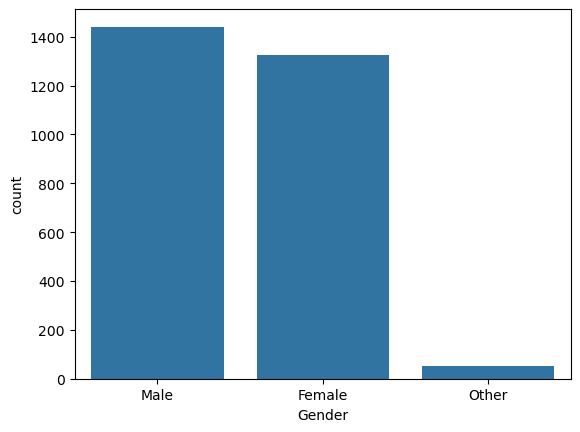

In [26]:
sns.countplot(x= df["Gender"])

# to invalid negative values from 3 cols

In [27]:
df.describe()

,CustomerAge,Quantity,UnitPrice,DiscountPercent,DeliveryDays,CustomerRating,ShippingCost
count,2910.000000,3000.000000,2925.000000,3000.000000,3000.000000,2160.000000,1950.000000
mean,34.683849,2.854333,997.884354,12.955000,5.834000,3.840278,52.010256
std,12.086021,10.648830,1030.098789,12.790524,4.604944,1.165725,46.232729
min,0.000000,-5.000000,80.350000,-25.000000,-3.000000,1.000000,0.000000
25%,28.000000,1.000000,478.610000,5.000000,4.000000,3.000000,0.000000
50%,34.000000,2.000000,786.670000,10.000000,5.000000,4.000000,60.000000
75%,41.000000,3.000000,1328.540000,20.000000,8.000000,5.000000,80.000000
max,150.000000,200.000000,20819.867889,150.000000,60.000000,5.000000,150.000000


In [28]:
# only clan min values

In [29]:
df[df['Quantity']<0] # chacking how many negative quantities are present in the columns

,OrderID,OrderDate,CustomerName,CustomerAge,Gender,CustomerCity,ProductCategory,ProductName,Quantity,UnitPrice,DiscountPercent,DeliveryDays,PaymentMethod,CustomerRating,ShippingCost,CouponCode,ReturnReason
617,ORD100213,2024-02-14,Myra Pillai,23.0,Male,Mumbai,Home & Kitchen,Steel Water Bottle,-5.0,587.12,5.0,8.0,Credit Card,NaN,40.0,NaN,NaN
779,ORD101643,2024-06-25,Myra Kulkarni,34.0,Female,Kochi,Electronics,Power Bank 10000mAh,-5.0,2055.66,10.0,6.0,Debit Card,4.0,100.0,NaN,NaN
835,ORD102838,2023-12-15,Diya Chopra,25.0,Female,Jaipur,Footwear,Formal Leather Shoes,-1.0,1001.25,5.0,4.0,NaN,4.0,0.0,NaN,NaN
1762,ORD102100,2025-04-11,Rohan Verma,28.0,Female,Chennai,Grocery,Spices Combo Pack,-1.0,217.70,15.0,5.0,Credit Card,4.0,0.0,NaN,NaN
2029,ORD101566,2025-06-01,Sneha Mehta,37.0,Female,Delhi,Footwear,Flip Flops,-5.0,2123.69,5.0,4.0,UPI,4.0,0.0,NaN,NaN
2145,ORD101800,2023-02-21,Sai Shah,26.0,Female,Kolkata,Grocery,Whole Wheat Atta 5kg,-5.0,525.48,10.0,8.0,Debit Card,4.0,0.0,NaN,NaN


In [30]:
df[df['DiscountPercent']<0] 

,OrderID,OrderDate,CustomerName,CustomerAge,Gender,CustomerCity,ProductCategory,ProductName,Quantity,UnitPrice,DiscountPercent,DeliveryDays,PaymentMethod,CustomerRating,ShippingCost,CouponCode,ReturnReason
288,ORD101609,2024-11-03,Arjun Reddy,50.0,Male,Jaipur,Footwear,Casual Sneakers,1.0,2126.40,-10.0,2.0,Credit Card,4.0,60.0,WELCOME50,NaN
478,ORD101163,2024-04-29,Sneha Pillai,15.0,Male,Nagpur,Grocery,Assorted Dry Fruits,3.0,253.78,-25.0,5.0,Debit Card,4.0,0.0,NaN,NaN
924,ORD102367,2023-06-10,Ishita Shah,37.0,Male,Jaipur,Grocery,Spices Combo Pack,1.0,464.64,-10.0,4.0,NaN,NaN,0.0,NaN,NaN
957,ORD101305,2024-09-03,Pooja Pillai,19.0,Female,Chandigarh,Electronics,Bluetooth Earbuds,2.0,863.56,-25.0,5.0,Credit Card,4.0,0.0,NaN,NaN
1722,ORD100823,2024-08-15,Pooja Rao,26.0,Female,Jaipur,Grocery,Honey 500g,1.0,417.11,-10.0,5.0,Debit Card,NaN,0.0,NaN,NaN
1953,ORD102865,2023-02-02,Anika Menon,27.0,Female,Ahmedabad,Electronics,USB-C Cable,5.0,759.10,-25.0,2.0,NaN,5.0,60.0,NaN,NaN
1965,ORD100949,2023-01-11,Vivaan Bhat,37.0,Female,Pune,Grocery,Honey 500g,2.0,477.69,-10.0,4.0,UPI,NaN,40.0,NaN,NaN
2291,ORD100135,2023-10-04,Ishaan Singh,34.0,Female,Nagpur,Footwear,Formal Leather Shoes,1.0,1924.22,-10.0,7.0,Debit Card,4.0,0.0,WELCOME50,Wrong Item Delivered
2920,ORD101258,2024-05-07,Kabir Singh,28.0,Other,Jaipur,Apparel,Denim Jeans,2.0,1101.89,-10.0,8.0,UPI,1.0,0.0,NaN,NaN
3052,ORD101639,2023-01-04,Karan Deshmukh,17.0,Female,Delhi,Apparel,Formal Shirt,2.0,569.21,-10.0,6.0,Credit Card,2.0,0.0,NaN,Defective Product


In [31]:
abs(-10)

10

In [32]:
df.columns

Index(['OrderID', 'OrderDate', 'CustomerName', 'CustomerAge', 'Gender',
       'CustomerCity', 'ProductCategory', 'ProductName', 'Quantity',
       'UnitPrice', 'DiscountPercent', 'DeliveryDays', 'PaymentMethod',
       'CustomerRating', 'ShippingCost', 'CouponCode', 'ReturnReason'],
      dtype='object')

In [33]:
negative = ['Quantity', 'DiscountPercent', 'DeliveryDays']
negative

['Quantity', 'DiscountPercent', 'DeliveryDays']

In [34]:
df['Quantity'].abs()

0       4.0
1       2.0
2       1.0
3       1.0
4       1.0
       ... 
3055    1.0
3056    4.0
3057    2.0
3058    1.0
3059    3.0
Name: Quantity, Length: 3000, dtype: float64

In [35]:
for i in negative:
    df[i] = df[i].abs()

In [36]:
df.describe()

,CustomerAge,Quantity,UnitPrice,DiscountPercent,DeliveryDays,CustomerRating,ShippingCost
count,2910.000000,3000.000000,2925.000000,3000.000000,3000.000000,2160.000000,1950.000000
mean,34.683849,2.869000,997.884354,13.051667,5.842000,3.840278,52.010256
std,12.086021,10.644887,1030.098789,12.691836,4.594788,1.165725,46.232729
min,0.000000,0.000000,80.350000,0.000000,1.000000,1.000000,0.000000
25%,28.000000,1.000000,478.610000,5.000000,4.000000,3.000000,0.000000
50%,34.000000,2.000000,786.670000,10.000000,5.000000,4.000000,60.000000
75%,41.000000,3.000000,1328.540000,20.000000,8.000000,5.000000,80.000000
max,150.000000,200.000000,20819.867889,150.000000,60.000000,5.000000,150.000000


# Cleaning age and dicountpercent

In [37]:
df.describe()

,CustomerAge,Quantity,UnitPrice,DiscountPercent,DeliveryDays,CustomerRating,ShippingCost
count,2910.000000,3000.000000,2925.000000,3000.000000,3000.000000,2160.000000,1950.000000
mean,34.683849,2.869000,997.884354,13.051667,5.842000,3.840278,52.010256
std,12.086021,10.644887,1030.098789,12.691836,4.594788,1.165725,46.232729
min,0.000000,0.000000,80.350000,0.000000,1.000000,1.000000,0.000000
25%,28.000000,1.000000,478.610000,5.000000,4.000000,3.000000,0.000000
50%,34.000000,2.000000,786.670000,10.000000,5.000000,4.000000,60.000000
75%,41.000000,3.000000,1328.540000,20.000000,8.000000,5.000000,80.000000
max,150.000000,200.000000,20819.867889,150.000000,60.000000,5.000000,150.000000


In [38]:
df[df['DiscountPercent']> 100]

,OrderID,OrderDate,CustomerName,CustomerAge,Gender,CustomerCity,ProductCategory,ProductName,Quantity,UnitPrice,DiscountPercent,DeliveryDays,PaymentMethod,CustomerRating,ShippingCost,CouponCode,ReturnReason
114,ORD102430,2023-05-01,Sara Gupta,39.0,Male,Delhi,Beauty & Personal Care,Sunscreen SPF50,2.0,770.10,150.0,5.0,Credit Card,3.0,40.0,FLAT100,NaN
613,ORD100453,2023-01-23,Kabir Bhat,42.0,Male,Delhi,Footwear,Sandals,4.0,1422.12,120.0,5.0,NaN,5.0,40.0,NaN,NaN
656,ORD102470,2025-03-23,Pari Iyer,57.0,NaN,Hyderabad,Footwear,Formal Leather Shoes,5.0,1501.22,120.0,9.0,UPI,4.0,0.0,WELCOME50,NaN
1654,ORD102209,2023-05-07,Karan Pillai,46.0,Female,Pune,Beauty & Personal Care,Body Lotion,4.0,527.66,120.0,5.0,UPI,5.0,NaN,NaN,NaN
2845,ORD102476,2024-04-20,Priya Bhat,25.0,Male,Mumbai,Grocery,Basmati Rice 5kg,3.0,219.99,120.0,7.0,UPI,4.0,80.0,NaN,NaN


In [39]:
df['DiscountPercent'].clip(upper = 100)

0        0.0
1       40.0
2       10.0
3        0.0
4       25.0
        ... 
3055    20.0
3056     5.0
3057    50.0
3058    25.0
3059    20.0
Name: DiscountPercent, Length: 3000, dtype: float64

In [40]:
df['DiscountPercent'] = df['DiscountPercent'].clip(lower= 0,upper = 100)

In [41]:
df['DiscountPercent']

0        0.0
1       40.0
2       10.0
3        0.0
4       25.0
        ... 
3055    20.0
3056     5.0
3057    50.0
3058    25.0
3059    20.0
Name: DiscountPercent, Length: 3000, dtype: float64

In [42]:
df.describe()

,CustomerAge,Quantity,UnitPrice,DiscountPercent,DeliveryDays,CustomerRating,ShippingCost
count,2910.000000,3000.000000,2925.000000,3000.000000,3000.000000,2160.000000,1950.000000
mean,34.683849,2.869000,997.884354,13.008333,5.842000,3.840278,52.010256
std,12.086021,10.644887,1030.098789,12.335950,4.594788,1.165725,46.232729
min,0.000000,0.000000,80.350000,0.000000,1.000000,1.000000,0.000000
25%,28.000000,1.000000,478.610000,5.000000,4.000000,3.000000,0.000000
50%,34.000000,2.000000,786.670000,10.000000,5.000000,4.000000,60.000000
75%,41.000000,3.000000,1328.540000,20.000000,8.000000,5.000000,80.000000
max,150.000000,200.000000,20819.867889,100.000000,60.000000,5.000000,150.000000


In [43]:
df.shape

(3000, 17)

In [44]:
 df[(df['CustomerAge']<16)| (df['CustomerAge']>75)]

,OrderID,OrderDate,CustomerName,CustomerAge,Gender,CustomerCity,ProductCategory,ProductName,Quantity,UnitPrice,DiscountPercent,DeliveryDays,PaymentMethod,CustomerRating,ShippingCost,CouponCode,ReturnReason
5,ORD102726,2023-05-05,Anika Pillai,15.0,Female,Pune,Electronics,LED Bulb Smart,2.0,2346.35,15.0,5.0,UPI,5.0,80.0,NaN,Size Issue
12,ORD100727,2023-01-10,Ishita Joshi,15.0,Male,Ahmedabad,Grocery,Whole Wheat Atta 5kg,4.0,405.44,0.0,8.0,NaN,4.0,NaN,NaN,NaN
46,ORD101236,2023-11-03,Sneha Joshi,15.0,Male,Ahmedabad,Grocery,Cooking Oil 1L,1.0,430.97,25.0,3.0,Net Banking,4.0,150.0,NaN,NaN
63,ORD101545,2024-06-21,Aadhya Menon,15.0,Male,Chennai,Footwear,Formal Leather Shoes,1.0,1211.00,5.0,9.0,Credit Card,NaN,0.0,NaN,NaN
81,ORD102141,2025-03-08,Priya Chopra,15.0,Male,Mumbai,Grocery,Honey 500g,1.0,613.70,25.0,6.0,UPI,2.0,40.0,FLAT100,Late Delivery
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2646,ORD101660,2024-07-18,Riya Reddy,120.0,Male,Kolkata,Beauty & Personal Care,Perfume 50ml,2.0,560.99,0.0,2.0,UPI,3.0,0.0,NaN,Wrong Item Delivered
2702,ORD101829,2024-01-02,Pari Mehta,15.0,Female,Chennai,Electronics,Wireless Mouse,1.0,1911.93,10.0,3.0,UPI,4.0,NaN,NaN,NaN
2837,ORD102569,2025-04-24,Amit Shah,15.0,Female,Ahmedabad,Apparel,Woolen Sweater,2.0,1009.54,10.0,6.0,Debit Card,NaN,100.0,NaN,NaN
2915,ORD101356,2023-12-15,Kabir Joshi,95.0,Female,Kolkata,Electronics,Smartphone Cover,3.0,1769.62,15.0,3.0,UPI,5.0,NaN,NaN,NaN


In [45]:
df.describe()

,CustomerAge,Quantity,UnitPrice,DiscountPercent,DeliveryDays,CustomerRating,ShippingCost
count,2910.000000,3000.000000,2925.000000,3000.000000,3000.000000,2160.000000,1950.000000
mean,34.683849,2.869000,997.884354,13.008333,5.842000,3.840278,52.010256
std,12.086021,10.644887,1030.098789,12.335950,4.594788,1.165725,46.232729
min,0.000000,0.000000,80.350000,0.000000,1.000000,1.000000,0.000000
25%,28.000000,1.000000,478.610000,5.000000,4.000000,3.000000,0.000000
50%,34.000000,2.000000,786.670000,10.000000,5.000000,4.000000,60.000000
75%,41.000000,3.000000,1328.540000,20.000000,8.000000,5.000000,80.000000
max,150.000000,200.000000,20819.867889,100.000000,60.000000,5.000000,150.000000


In [46]:
np.nan

nan

In [47]:
  df.loc[(df['CustomerAge']<16)| (df['CustomerAge']>75),'CustomerAge'] = np.nan

In [48]:
df.describe()

,CustomerAge,Quantity,UnitPrice,DiscountPercent,DeliveryDays,CustomerRating,ShippingCost
count,2798.000000,3000.000000,2925.000000,3000.000000,3000.000000,2160.000000,1950.000000
mean,34.652252,2.869000,997.884354,13.008333,5.842000,3.840278,52.010256
std,9.281069,10.644887,1030.098789,12.335950,4.594788,1.165725,46.232729
min,16.000000,0.000000,80.350000,0.000000,1.000000,1.000000,0.000000
25%,28.000000,1.000000,478.610000,5.000000,4.000000,3.000000,0.000000
50%,34.000000,2.000000,786.670000,10.000000,5.000000,4.000000,60.000000
75%,41.000000,3.000000,1328.540000,20.000000,8.000000,5.000000,80.000000
max,70.000000,200.000000,20819.867889,100.000000,60.000000,5.000000,150.000000


# Dealing missing Values

-  If the missing values in a columns in between 0 to 5% ---> drop rows with NA
-  if the missing values in a columns in between 5 to 50%  ------> Replace NA
- conatian more than 50% of NA value ---> Delete columns with NA
- check missing values   using  --->  df.isna().sum()

In [49]:
df.isna().sum()  #finding count of NA in all columns

OrderID               0
OrderDate             0
CustomerName          0
CustomerAge         202
Gender              180
CustomerCity        240
ProductCategory       0
ProductName           0
Quantity              0
UnitPrice            75
DiscountPercent       0
DeliveryDays          0
PaymentMethod       540
CustomerRating      840
ShippingCost       1050
CouponCode         2160
ReturnReason       2640
dtype: int64

In [50]:
df.describe()

,CustomerAge,Quantity,UnitPrice,DiscountPercent,DeliveryDays,CustomerRating,ShippingCost
count,2798.000000,3000.000000,2925.000000,3000.000000,3000.000000,2160.000000,1950.000000
mean,34.652252,2.869000,997.884354,13.008333,5.842000,3.840278,52.010256
std,9.281069,10.644887,1030.098789,12.335950,4.594788,1.165725,46.232729
min,16.000000,0.000000,80.350000,0.000000,1.000000,1.000000,0.000000
25%,28.000000,1.000000,478.610000,5.000000,4.000000,3.000000,0.000000
50%,34.000000,2.000000,786.670000,10.000000,5.000000,4.000000,60.000000
75%,41.000000,3.000000,1328.540000,20.000000,8.000000,5.000000,80.000000
max,70.000000,200.000000,20819.867889,100.000000,60.000000,5.000000,150.000000


In [51]:
(df.isna().sum()/3000)*100    # perccentage of NA values

OrderID             0.000000
OrderDate           0.000000
CustomerName        0.000000
CustomerAge         6.733333
Gender              6.000000
CustomerCity        8.000000
ProductCategory     0.000000
ProductName         0.000000
Quantity            0.000000
UnitPrice           2.500000
DiscountPercent     0.000000
DeliveryDays        0.000000
PaymentMethod      18.000000
CustomerRating     28.000000
ShippingCost       35.000000
CouponCode         72.000000
ReturnReason       88.000000
dtype: float64

In [52]:
#for row delete using  dropna function   0 to 5% ------>
df.dropna(subset = ['UnitPrice'],inplace =True)

In [53]:
(df.isna().sum()/3000)*100 

OrderID             0.000000
OrderDate           0.000000
CustomerName        0.000000
CustomerAge         6.533333
Gender              5.766667
CustomerCity        7.700000
ProductCategory     0.000000
ProductName         0.000000
Quantity            0.000000
UnitPrice           0.000000
DiscountPercent     0.000000
DeliveryDays        0.000000
PaymentMethod      17.733333
CustomerRating     27.366667
ShippingCost       34.200000
CouponCode         70.133333
ReturnReason       85.666667
dtype: float64

# Replacing missing (NA)values  5 to 50% ------>

In [54]:
#customerage,genfer,customercity,paymentmethod,customerating,shippingcost

In [55]:
df.head()

,OrderID,OrderDate,CustomerName,CustomerAge,Gender,CustomerCity,ProductCategory,ProductName,Quantity,UnitPrice,DiscountPercent,DeliveryDays,PaymentMethod,CustomerRating,ShippingCost,CouponCode,ReturnReason
0,ORD100674,2024-07-20,Diya Verma,34.0,Male,Delhi,Beauty & Personal Care,Lip Balm Pack,4.0,144.70,0.0,4.0,Net Banking,4.0,0.0,NaN,NaN
1,ORD102063,2024-10-17,Reyansh Sharma,31.0,Male,Kolkata,Footwear,Formal Leather Shoes,2.0,486.07,40.0,2.0,Debit Card,NaN,0.0,NEWUSER15,NaN
2,ORD100377,2024-11-11,Sara Deshmukh,51.0,Male,Pune,Apparel,Men Cotton T-Shirt,1.0,852.46,10.0,3.0,Credit Card,4.0,NaN,FEST20,NaN
3,ORD100802,2024-04-14,Riya Kapoor,49.0,NaN,Nagpur,Apparel,Men Cotton T-Shirt,1.0,1246.09,0.0,2.0,NaN,NaN,NaN,NEWUSER15,NaN
4,ORD101208,2023-09-17,Sneha Pillai,39.0,Male,Lucknow,Grocery,Green Tea Pack,1.0,379.31,25.0,4.0,Debit Card,NaN,80.0,FLAT100,NaN


In [56]:
print(df['CustomerAge'].median())

34.0


In [57]:
print(df['Gender'].mode())
print(df['CustomerCity'].mode())
print(df['PaymentMethod'].mode())

0    Male
Name: Gender, dtype: object
0    Lucknow
Name: CustomerCity, dtype: object
0    UPI
Name: PaymentMethod, dtype: object


In [58]:
df.fillna({'CustomerAge':34,'Gender':'Male','CustomerCity':'Lucknow','PaymentMethod':'UPI','CustomerRating':0,'ShippingCost':0},inplace= True)

df.isna().sum()

In [59]:
df.head()

,OrderID,OrderDate,CustomerName,CustomerAge,Gender,CustomerCity,ProductCategory,ProductName,Quantity,UnitPrice,DiscountPercent,DeliveryDays,PaymentMethod,CustomerRating,ShippingCost,CouponCode,ReturnReason
0,ORD100674,2024-07-20,Diya Verma,34.0,Male,Delhi,Beauty & Personal Care,Lip Balm Pack,4.0,144.70,0.0,4.0,Net Banking,4.0,0.0,NaN,NaN
1,ORD102063,2024-10-17,Reyansh Sharma,31.0,Male,Kolkata,Footwear,Formal Leather Shoes,2.0,486.07,40.0,2.0,Debit Card,0.0,0.0,NEWUSER15,NaN
2,ORD100377,2024-11-11,Sara Deshmukh,51.0,Male,Pune,Apparel,Men Cotton T-Shirt,1.0,852.46,10.0,3.0,Credit Card,4.0,0.0,FEST20,NaN
3,ORD100802,2024-04-14,Riya Kapoor,49.0,Male,Nagpur,Apparel,Men Cotton T-Shirt,1.0,1246.09,0.0,2.0,UPI,0.0,0.0,NEWUSER15,NaN
4,ORD101208,2023-09-17,Sneha Pillai,39.0,Male,Lucknow,Grocery,Green Tea Pack,1.0,379.31,25.0,4.0,Debit Card,0.0,80.0,FLAT100,NaN


# convert Date columns

- year
- month_name
- day_name
- quater


In [60]:
df.head()

,OrderID,OrderDate,CustomerName,CustomerAge,Gender,CustomerCity,ProductCategory,ProductName,Quantity,UnitPrice,DiscountPercent,DeliveryDays,PaymentMethod,CustomerRating,ShippingCost,CouponCode,ReturnReason
0,ORD100674,2024-07-20,Diya Verma,34.0,Male,Delhi,Beauty & Personal Care,Lip Balm Pack,4.0,144.70,0.0,4.0,Net Banking,4.0,0.0,NaN,NaN
1,ORD102063,2024-10-17,Reyansh Sharma,31.0,Male,Kolkata,Footwear,Formal Leather Shoes,2.0,486.07,40.0,2.0,Debit Card,0.0,0.0,NEWUSER15,NaN
2,ORD100377,2024-11-11,Sara Deshmukh,51.0,Male,Pune,Apparel,Men Cotton T-Shirt,1.0,852.46,10.0,3.0,Credit Card,4.0,0.0,FEST20,NaN
3,ORD100802,2024-04-14,Riya Kapoor,49.0,Male,Nagpur,Apparel,Men Cotton T-Shirt,1.0,1246.09,0.0,2.0,UPI,0.0,0.0,NEWUSER15,NaN
4,ORD101208,2023-09-17,Sneha Pillai,39.0,Male,Lucknow,Grocery,Green Tea Pack,1.0,379.31,25.0,4.0,Debit Card,0.0,80.0,FLAT100,NaN


In [61]:
df['OrderDate']=pd.to_datetime(df['OrderDate'])  # for convert str to datetime datatype  then use function on it

In [62]:
df.head()

,OrderID,OrderDate,CustomerName,CustomerAge,Gender,CustomerCity,ProductCategory,ProductName,Quantity,UnitPrice,DiscountPercent,DeliveryDays,PaymentMethod,CustomerRating,ShippingCost,CouponCode,ReturnReason
0,ORD100674,2024-07-20,Diya Verma,34.0,Male,Delhi,Beauty & Personal Care,Lip Balm Pack,4.0,144.70,0.0,4.0,Net Banking,4.0,0.0,NaN,NaN
1,ORD102063,2024-10-17,Reyansh Sharma,31.0,Male,Kolkata,Footwear,Formal Leather Shoes,2.0,486.07,40.0,2.0,Debit Card,0.0,0.0,NEWUSER15,NaN
2,ORD100377,2024-11-11,Sara Deshmukh,51.0,Male,Pune,Apparel,Men Cotton T-Shirt,1.0,852.46,10.0,3.0,Credit Card,4.0,0.0,FEST20,NaN
3,ORD100802,2024-04-14,Riya Kapoor,49.0,Male,Nagpur,Apparel,Men Cotton T-Shirt,1.0,1246.09,0.0,2.0,UPI,0.0,0.0,NEWUSER15,NaN
4,ORD101208,2023-09-17,Sneha Pillai,39.0,Male,Lucknow,Grocery,Green Tea Pack,1.0,379.31,25.0,4.0,Debit Card,0.0,80.0,FLAT100,NaN


In [63]:
df.dtypes

OrderID                    object
OrderDate          datetime64[ns]
CustomerName               object
CustomerAge               float64
Gender                     object
CustomerCity               object
ProductCategory            object
ProductName                object
Quantity                  float64
UnitPrice                 float64
DiscountPercent           float64
DeliveryDays              float64
PaymentMethod              object
CustomerRating            float64
ShippingCost              float64
CouponCode                 object
ReturnReason               object
dtype: object

In [64]:
df['Year'] = df['OrderDate'].dt.year    # also know as feature engineering  mean to add columns base on main column  orderdate
df['Monthname']=  df['OrderDate'].dt.month_name()
df['Dayname'] = df['OrderDate'].dt.day_name()
df['Quarter'] = df['OrderDate'].dt.quarter

In [65]:
df.head()

,OrderID,OrderDate,CustomerName,CustomerAge,Gender,CustomerCity,ProductCategory,ProductName,Quantity,UnitPrice,...,DeliveryDays,PaymentMethod,CustomerRating,ShippingCost,CouponCode,ReturnReason,Year,Monthname,Dayname,Quarter
0,ORD100674,2024-07-20,Diya Verma,34.0,Male,Delhi,Beauty & Personal Care,Lip Balm Pack,4.0,144.70,...,4.0,Net Banking,4.0,0.0,NaN,NaN,2024,July,Saturday,3
1,ORD102063,2024-10-17,Reyansh Sharma,31.0,Male,Kolkata,Footwear,Formal Leather Shoes,2.0,486.07,...,2.0,Debit Card,0.0,0.0,NEWUSER15,NaN,2024,October,Thursday,4
2,ORD100377,2024-11-11,Sara Deshmukh,51.0,Male,Pune,Apparel,Men Cotton T-Shirt,1.0,852.46,...,3.0,Credit Card,4.0,0.0,FEST20,NaN,2024,November,Monday,4
3,ORD100802,2024-04-14,Riya Kapoor,49.0,Male,Nagpur,Apparel,Men Cotton T-Shirt,1.0,1246.09,...,2.0,UPI,0.0,0.0,NEWUSER15,NaN,2024,April,Sunday,2
4,ORD101208,2023-09-17,Sneha Pillai,39.0,Male,Lucknow,Grocery,Green Tea Pack,1.0,379.31,...,4.0,Debit Card,0.0,80.0,FLAT100,NaN,2023,September,Sunday,3


In [66]:
df.columns

Index(['OrderID', 'OrderDate', 'CustomerName', 'CustomerAge', 'Gender',
       'CustomerCity', 'ProductCategory', 'ProductName', 'Quantity',
       'UnitPrice', 'DiscountPercent', 'DeliveryDays', 'PaymentMethod',
       'CustomerRating', 'ShippingCost', 'CouponCode', 'ReturnReason', 'Year',
       'Monthname', 'Dayname', 'Quarter'],
      dtype='object')

In [67]:
df['DiscountPercent']

0        0.0
1       40.0
2       10.0
3        0.0
4       25.0
        ... 
3054     0.0
3055    20.0
3056     5.0
3057    50.0
3058    25.0
Name: DiscountPercent, Length: 2925, dtype: float64

In [68]:
df['sales'] = df['Quantity']* df['UnitPrice'] *(1-df['DiscountPercent']/100)+ df['ShippingCost']

In [69]:
df.head()

,OrderID,OrderDate,CustomerName,CustomerAge,Gender,CustomerCity,ProductCategory,ProductName,Quantity,UnitPrice,...,PaymentMethod,CustomerRating,ShippingCost,CouponCode,ReturnReason,Year,Monthname,Dayname,Quarter,sales
0,ORD100674,2024-07-20,Diya Verma,34.0,Male,Delhi,Beauty & Personal Care,Lip Balm Pack,4.0,144.70,...,Net Banking,4.0,0.0,NaN,NaN,2024,July,Saturday,3,578.8000
1,ORD102063,2024-10-17,Reyansh Sharma,31.0,Male,Kolkata,Footwear,Formal Leather Shoes,2.0,486.07,...,Debit Card,0.0,0.0,NEWUSER15,NaN,2024,October,Thursday,4,583.2840
2,ORD100377,2024-11-11,Sara Deshmukh,51.0,Male,Pune,Apparel,Men Cotton T-Shirt,1.0,852.46,...,Credit Card,4.0,0.0,FEST20,NaN,2024,November,Monday,4,767.2140
3,ORD100802,2024-04-14,Riya Kapoor,49.0,Male,Nagpur,Apparel,Men Cotton T-Shirt,1.0,1246.09,...,UPI,0.0,0.0,NEWUSER15,NaN,2024,April,Sunday,2,1246.0900
4,ORD101208,2023-09-17,Sneha Pillai,39.0,Male,Lucknow,Grocery,Green Tea Pack,1.0,379.31,...,Debit Card,0.0,80.0,FLAT100,NaN,2023,September,Sunday,3,364.4825


In [70]:
df.describe()

,OrderDate,CustomerAge,Quantity,UnitPrice,DiscountPercent,DeliveryDays,CustomerRating,ShippingCost,Year,Quarter,sales
count,2925,2925.000000,2925.000000,2925.000000,2925.000000,2925.000000,2925.000000,2925.000000,2925.000000,2925.000000,2925.000000
mean,2024-03-20 20:16:59.076922880,34.609573,2.748376,997.884354,12.994872,5.837265,2.757265,33.856410,2023.715897,2.545299,2359.741422
min,2023-01-01 00:00:00,16.000000,0.000000,80.350000,0.000000,1.000000,0.000000,0.000000,2023.000000,1.000000,0.000000
25%,2023-09-22 00:00:00,29.000000,1.000000,478.610000,5.000000,4.000000,0.000000,0.000000,2023.000000,1.000000,644.592000
50%,2024-02-14 00:00:00,34.000000,2.000000,786.670000,10.000000,5.000000,3.000000,0.000000,2024.000000,2.000000,1236.720000
75%,2024-11-06 00:00:00,40.000000,3.000000,1328.540000,20.000000,8.000000,5.000000,60.000000,2024.000000,4.000000,2309.840000
max,2025-06-29 00:00:00,70.000000,200.000000,20819.867889,100.000000,60.000000,5.000000,150.000000,2025.000000,4.000000,261862.125000
std,NaN,8.952300,9.853663,1030.098789,12.356771,4.552346,1.987621,44.937636,0.704905,1.220163,8937.501977


In [71]:
def Quantiy(number):
    if number<= 5:
        return'low'
    elif number<=10:
        return'medium'
    elif number<=100:
        return'high large'
    else:
        return ' very large'


In [72]:
df['QuantityType']= df['Quantity'].apply(Quantiy) 

In [73]:
df.head()

,OrderID,OrderDate,CustomerName,CustomerAge,Gender,CustomerCity,ProductCategory,ProductName,Quantity,UnitPrice,...,CustomerRating,ShippingCost,CouponCode,ReturnReason,Year,Monthname,Dayname,Quarter,sales,QuantityType
0,ORD100674,2024-07-20,Diya Verma,34.0,Male,Delhi,Beauty & Personal Care,Lip Balm Pack,4.0,144.70,...,4.0,0.0,NaN,NaN,2024,July,Saturday,3,578.8000,low
1,ORD102063,2024-10-17,Reyansh Sharma,31.0,Male,Kolkata,Footwear,Formal Leather Shoes,2.0,486.07,...,0.0,0.0,NEWUSER15,NaN,2024,October,Thursday,4,583.2840,low
2,ORD100377,2024-11-11,Sara Deshmukh,51.0,Male,Pune,Apparel,Men Cotton T-Shirt,1.0,852.46,...,4.0,0.0,FEST20,NaN,2024,November,Monday,4,767.2140,low
3,ORD100802,2024-04-14,Riya Kapoor,49.0,Male,Nagpur,Apparel,Men Cotton T-Shirt,1.0,1246.09,...,0.0,0.0,NEWUSER15,NaN,2024,April,Sunday,2,1246.0900,low
4,ORD101208,2023-09-17,Sneha Pillai,39.0,Male,Lucknow,Grocery,Green Tea Pack,1.0,379.31,...,0.0,80.0,FLAT100,NaN,2023,September,Sunday,3,364.4825,low


In [74]:
df['QuantityType'].unique()

array(['low', 'high large', ' very large'], dtype=object)

In [75]:
df.tail()

,OrderID,OrderDate,CustomerName,CustomerAge,Gender,CustomerCity,ProductCategory,ProductName,Quantity,UnitPrice,...,CustomerRating,ShippingCost,CouponCode,ReturnReason,Year,Monthname,Dayname,Quarter,sales,QuantityType
3054,ORD100211,2024-10-15,Amit Menon,49.0,Female,Kochi,Home & Kitchen,Storage Container Set,3.0,655.70,...,5.0,60.0,NaN,NaN,2024,October,Tuesday,4,2027.100,low
3055,ORD101603,2023-10-16,Reyansh Deshmukh,24.0,Male,Delhi,Apparel,Sports Track Pant,1.0,468.47,...,0.0,0.0,NaN,Size Issue,2023,October,Monday,4,374.776,low
3056,ORD102550,2024-11-13,Anika Kulkarni,48.0,Female,Jaipur,Home & Kitchen,Non-Stick Pan,4.0,1360.28,...,5.0,0.0,NaN,NaN,2024,November,Wednesday,4,5169.064,low
3057,ORD100537,2023-04-16,Myra Bhat,33.0,Female,Chandigarh,Beauty & Personal Care,Hair Oil 200ml,2.0,695.55,...,0.0,80.0,NaN,NaN,2023,April,Sunday,2,775.550,low
3058,ORD101220,2024-08-14,Reyansh Iyer,24.0,Female,Lucknow,Grocery,Instant Noodles Pack,1.0,608.30,...,4.0,0.0,SAVE10,NaN,2024,August,Wednesday,3,456.225,low


# Univariate analysis

- barplot
- histogram
- pie

In [76]:
#selecting only text columns name and converting it into list

In [77]:
df.head()

,OrderID,OrderDate,CustomerName,CustomerAge,Gender,CustomerCity,ProductCategory,ProductName,Quantity,UnitPrice,...,CustomerRating,ShippingCost,CouponCode,ReturnReason,Year,Monthname,Dayname,Quarter,sales,QuantityType
0,ORD100674,2024-07-20,Diya Verma,34.0,Male,Delhi,Beauty & Personal Care,Lip Balm Pack,4.0,144.70,...,4.0,0.0,NaN,NaN,2024,July,Saturday,3,578.8000,low
1,ORD102063,2024-10-17,Reyansh Sharma,31.0,Male,Kolkata,Footwear,Formal Leather Shoes,2.0,486.07,...,0.0,0.0,NEWUSER15,NaN,2024,October,Thursday,4,583.2840,low
2,ORD100377,2024-11-11,Sara Deshmukh,51.0,Male,Pune,Apparel,Men Cotton T-Shirt,1.0,852.46,...,4.0,0.0,FEST20,NaN,2024,November,Monday,4,767.2140,low
3,ORD100802,2024-04-14,Riya Kapoor,49.0,Male,Nagpur,Apparel,Men Cotton T-Shirt,1.0,1246.09,...,0.0,0.0,NEWUSER15,NaN,2024,April,Sunday,2,1246.0900,low
4,ORD101208,2023-09-17,Sneha Pillai,39.0,Male,Lucknow,Grocery,Green Tea Pack,1.0,379.31,...,0.0,80.0,FLAT100,NaN,2023,September,Sunday,3,364.4825,low


In [78]:
df.dtypes

OrderID                    object
OrderDate          datetime64[ns]
CustomerName               object
CustomerAge               float64
Gender                     object
CustomerCity               object
ProductCategory            object
ProductName                object
Quantity                  float64
UnitPrice                 float64
DiscountPercent           float64
DeliveryDays              float64
PaymentMethod              object
CustomerRating            float64
ShippingCost              float64
CouponCode                 object
ReturnReason               object
Year                        int32
Monthname                  object
Dayname                    object
Quarter                     int32
sales                     float64
QuantityType               object
dtype: object

In [79]:
#all string columnns,all int, customerRanting

In [80]:
df.select_dtypes([object,int]).drop(columns = ['OrderID','CustomerName']).columns

Index(['Gender', 'CustomerCity', 'ProductCategory', 'ProductName',
       'PaymentMethod', 'CouponCode', 'ReturnReason', 'Year', 'Monthname',
       'Dayname', 'Quarter', 'QuantityType'],
      dtype='object')

In [81]:
univariate = list(df.select_dtypes([object,int]).drop(columns = ['OrderID','CustomerName']).columns)
univariate.append('CustomerRating')
univariate

['Gender',
 'CustomerCity',
 'ProductCategory',
 'ProductName',
 'PaymentMethod',
 'CouponCode',
 'ReturnReason',
 'Year',
 'Monthname',
 'Dayname',
 'Quarter',
 'QuantityType',
 'CustomerRating']

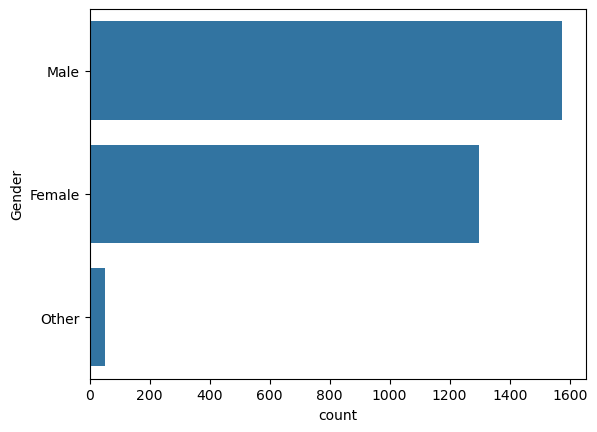

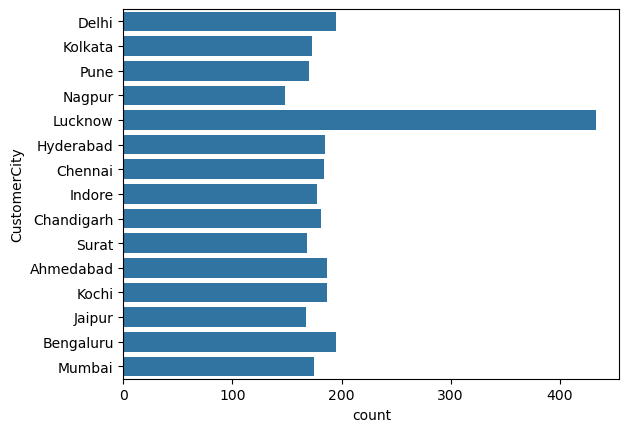

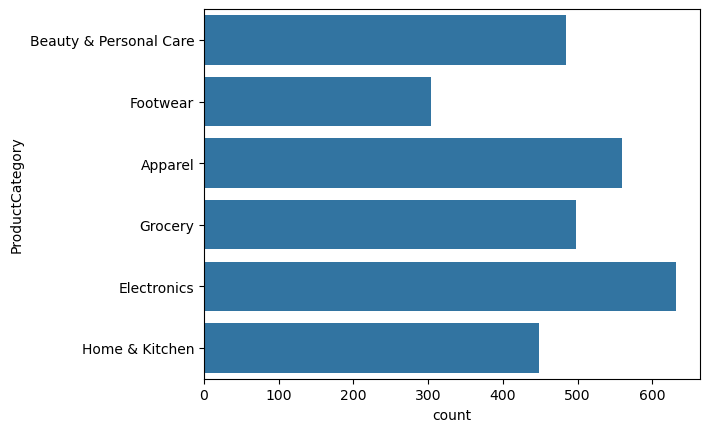

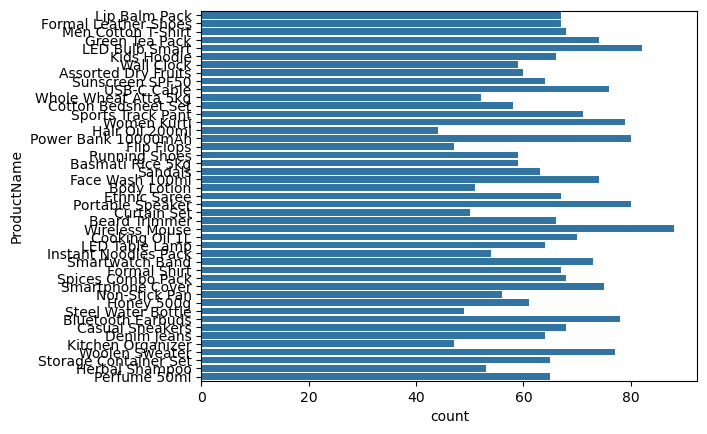

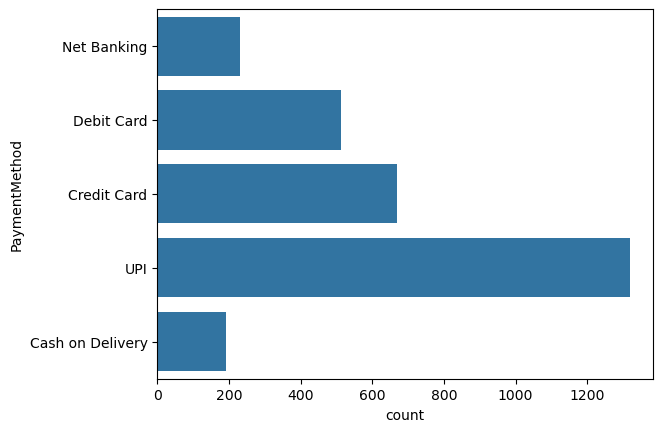

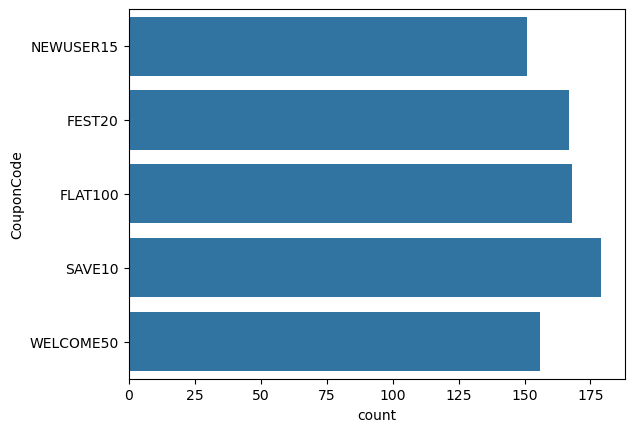

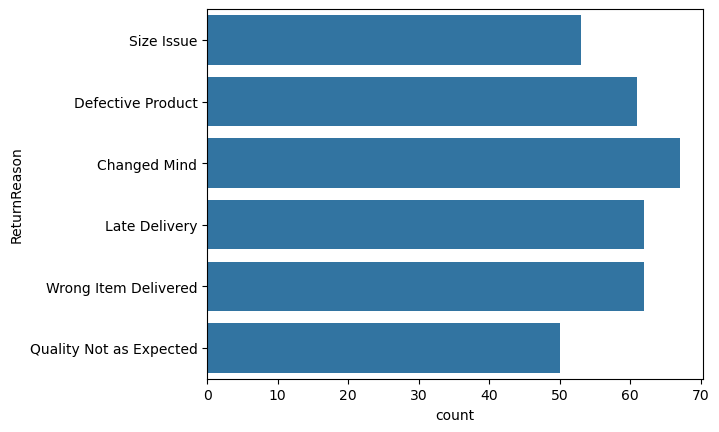

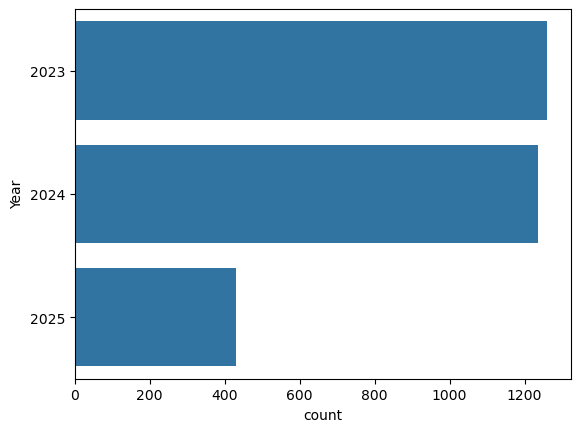

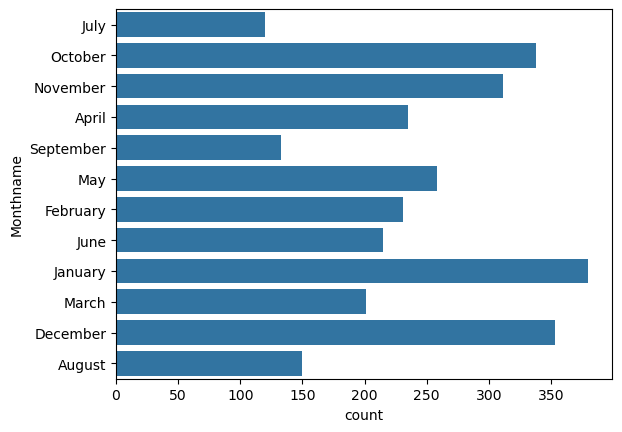

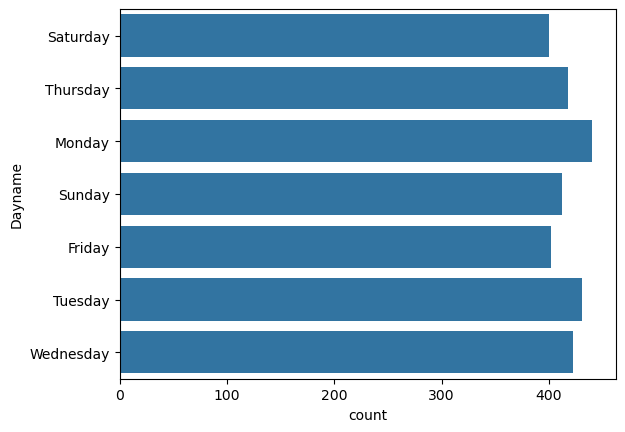

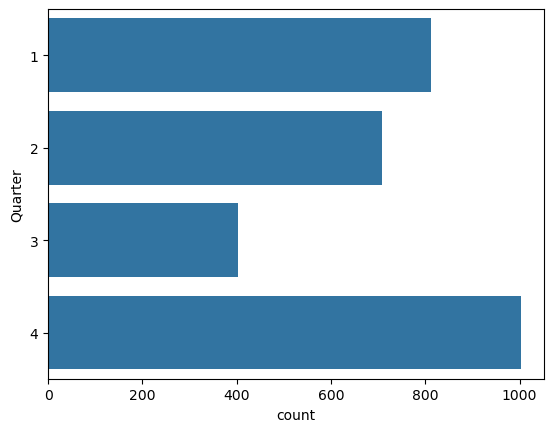

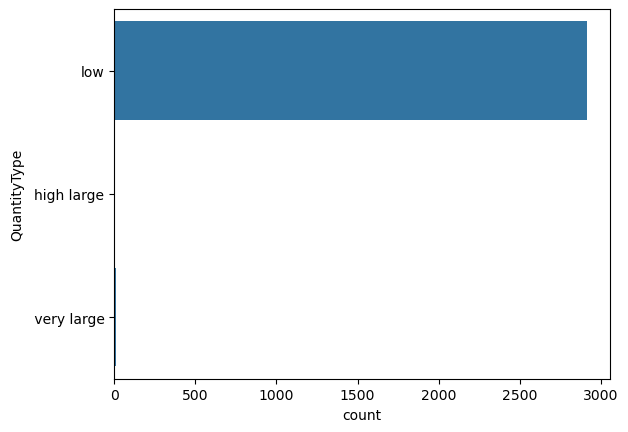

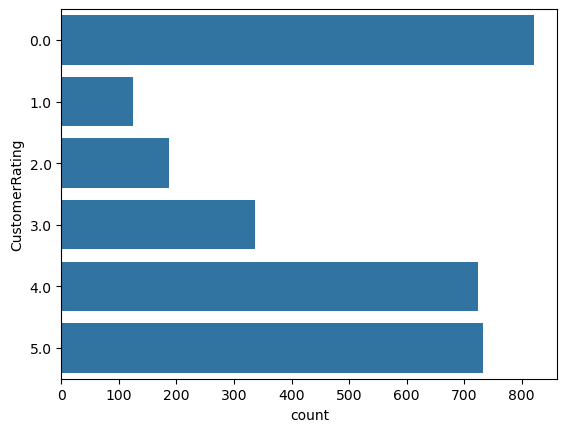

In [82]:
for i in univariate:
    sns.countplot(y= df[i])
    plt.show()

In [83]:
df.dtypes

OrderID                    object
OrderDate          datetime64[ns]
CustomerName               object
CustomerAge               float64
Gender                     object
CustomerCity               object
ProductCategory            object
ProductName                object
Quantity                  float64
UnitPrice                 float64
DiscountPercent           float64
DeliveryDays              float64
PaymentMethod              object
CustomerRating            float64
ShippingCost              float64
CouponCode                 object
ReturnReason               object
Year                        int32
Monthname                  object
Dayname                    object
Quarter                     int32
sales                     float64
QuantityType               object
dtype: object

In [84]:
# for float values columns  create histogram

In [85]:
numeric = df.select_dtypes(float).columns
numeric

Index(['CustomerAge', 'Quantity', 'UnitPrice', 'DiscountPercent',
       'DeliveryDays', 'CustomerRating', 'ShippingCost', 'sales'],
      dtype='object')

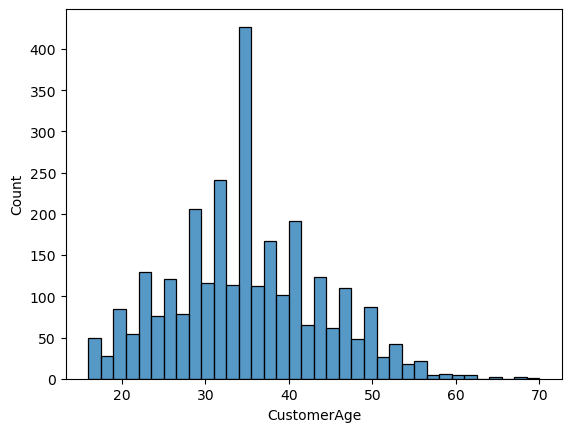

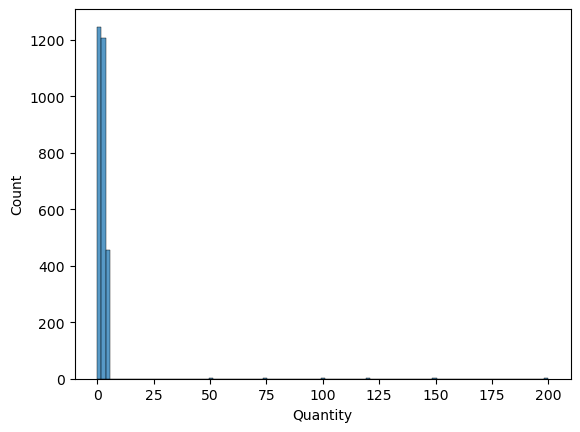

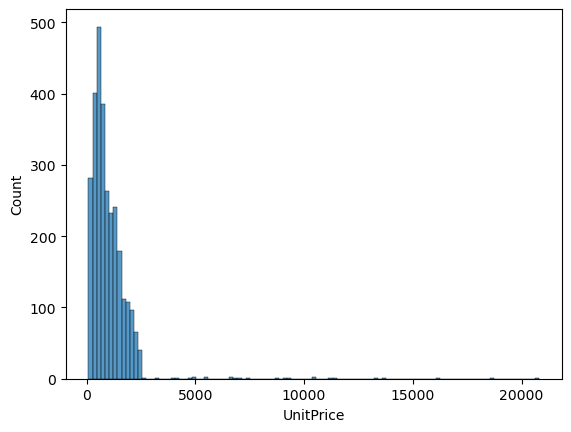

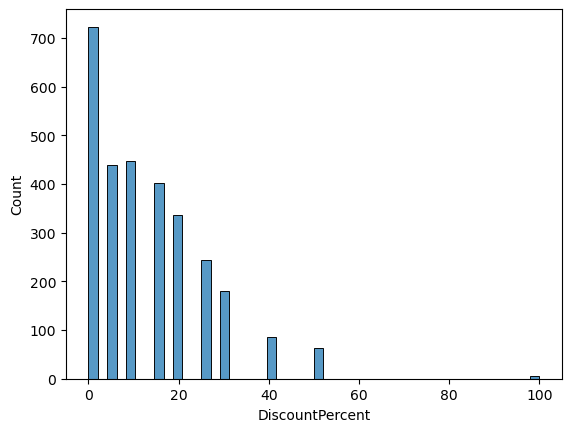

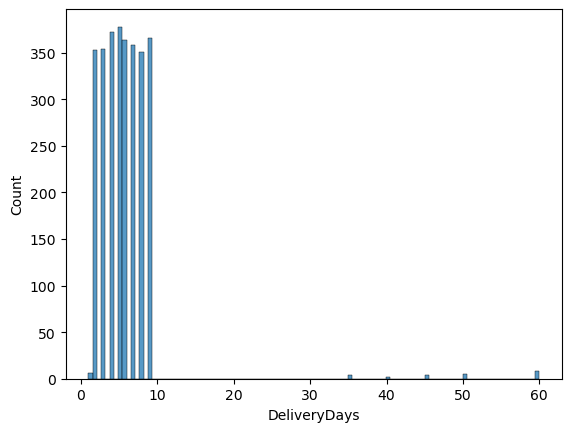

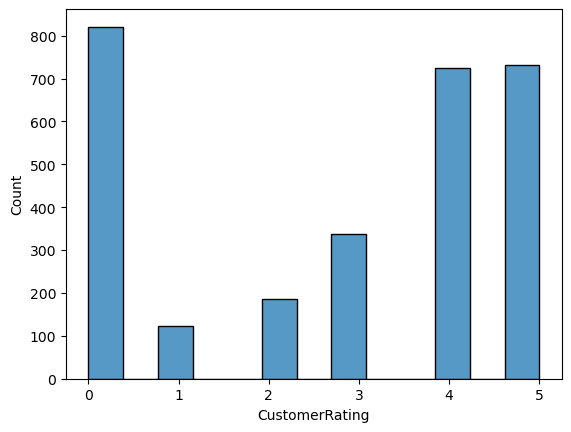

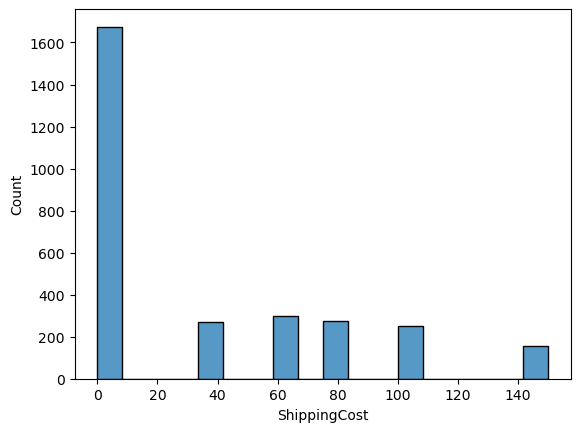

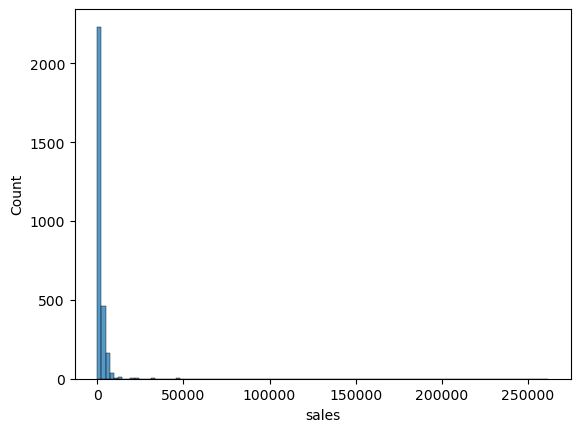

In [86]:
for i in numeric:                
    sns.histplot(x= df[i])
    plt.show()

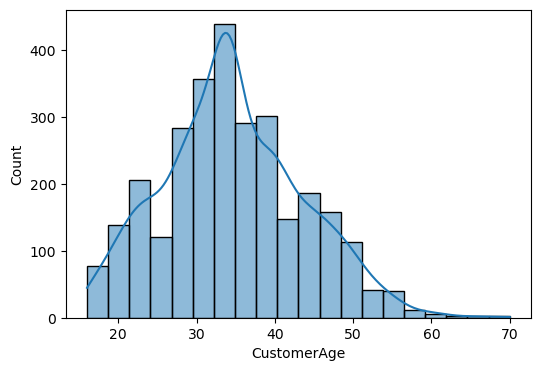

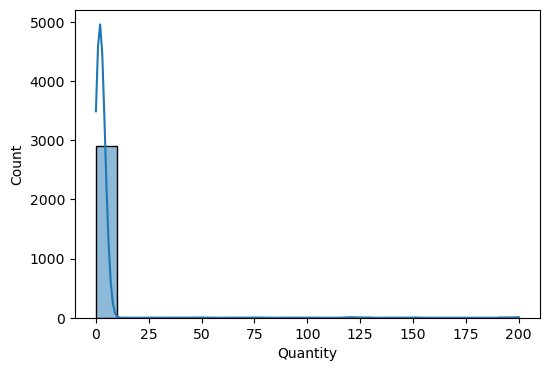

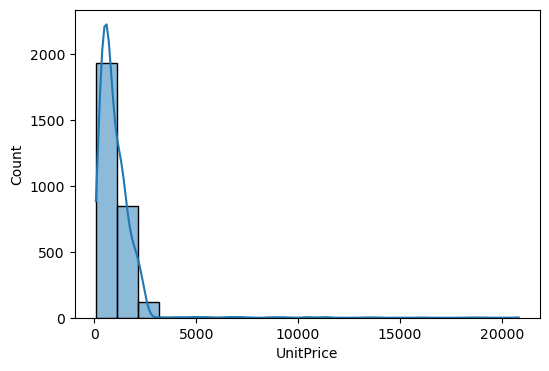

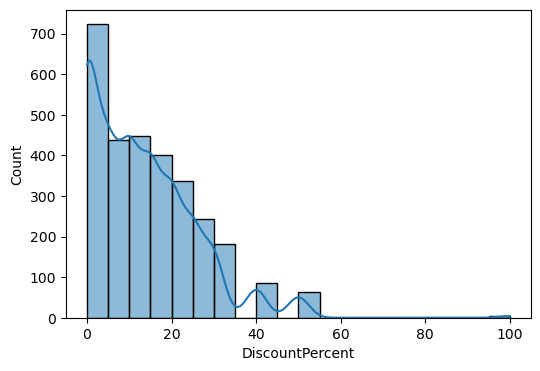

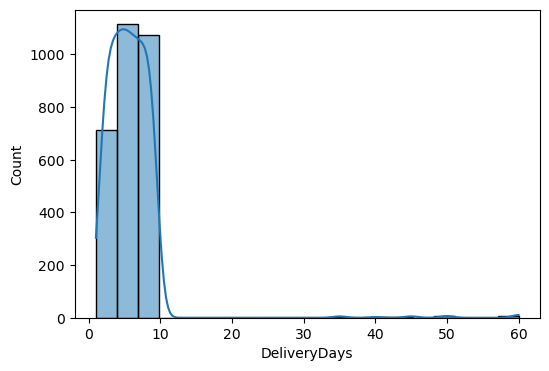

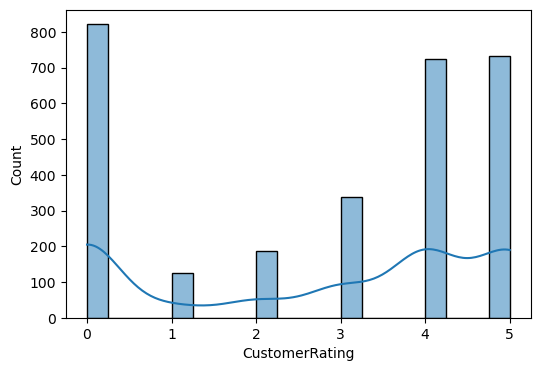

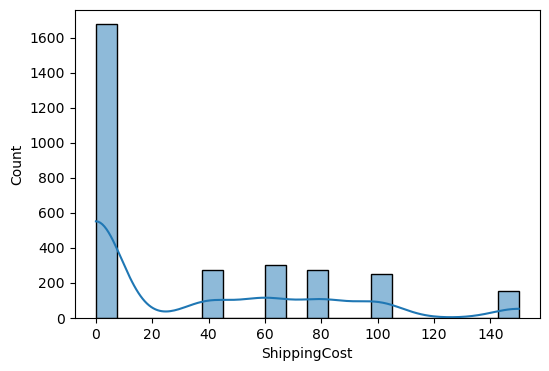

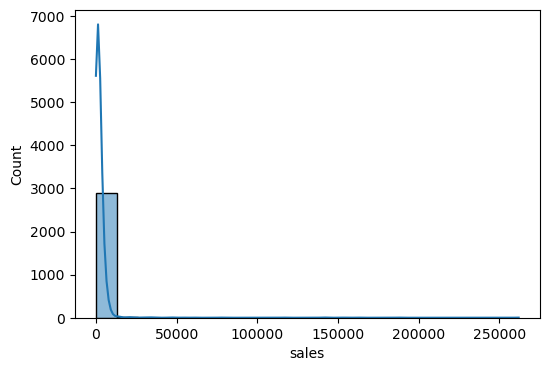

In [87]:

for i in numeric:
    plt.figure(figsize=(6,4))
    sns.histplot(df[i],kde = True, bins = 20)
    plt.show()

<Axes: ylabel='count'>

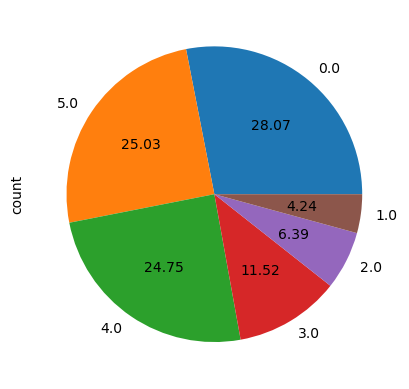

In [88]:
df['CustomerRating'].value_counts().plot(kind = 'pie',autopct = '%0.02f')  # autopct for percentage display in pie chart

<Axes: >

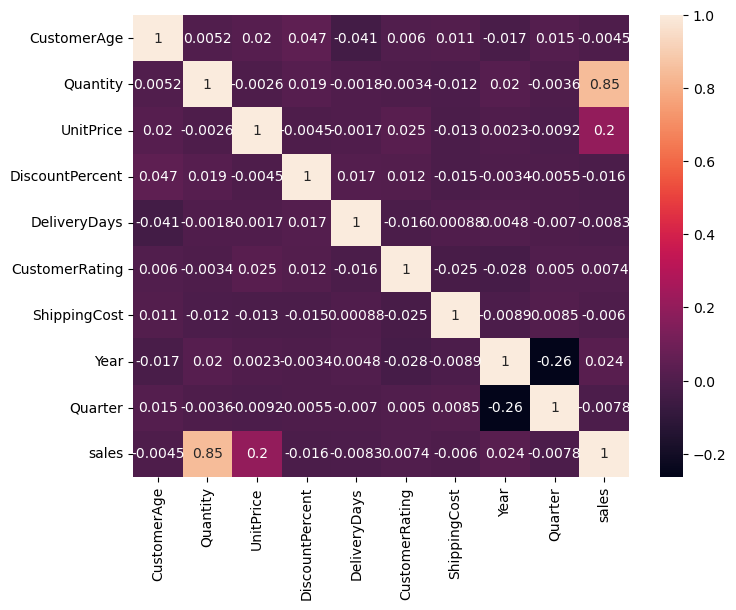

In [89]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only= True),annot= True)

# Bivariate analysis

- pairplot shows almost all columns are non related to each  other except values,sales

In [90]:
df.head()

,OrderID,OrderDate,CustomerName,CustomerAge,Gender,CustomerCity,ProductCategory,ProductName,Quantity,UnitPrice,...,CustomerRating,ShippingCost,CouponCode,ReturnReason,Year,Monthname,Dayname,Quarter,sales,QuantityType
0,ORD100674,2024-07-20,Diya Verma,34.0,Male,Delhi,Beauty & Personal Care,Lip Balm Pack,4.0,144.70,...,4.0,0.0,NaN,NaN,2024,July,Saturday,3,578.8000,low
1,ORD102063,2024-10-17,Reyansh Sharma,31.0,Male,Kolkata,Footwear,Formal Leather Shoes,2.0,486.07,...,0.0,0.0,NEWUSER15,NaN,2024,October,Thursday,4,583.2840,low
2,ORD100377,2024-11-11,Sara Deshmukh,51.0,Male,Pune,Apparel,Men Cotton T-Shirt,1.0,852.46,...,4.0,0.0,FEST20,NaN,2024,November,Monday,4,767.2140,low
3,ORD100802,2024-04-14,Riya Kapoor,49.0,Male,Nagpur,Apparel,Men Cotton T-Shirt,1.0,1246.09,...,0.0,0.0,NEWUSER15,NaN,2024,April,Sunday,2,1246.0900,low
4,ORD101208,2023-09-17,Sneha Pillai,39.0,Male,Lucknow,Grocery,Green Tea Pack,1.0,379.31,...,0.0,80.0,FLAT100,NaN,2023,September,Sunday,3,364.4825,low


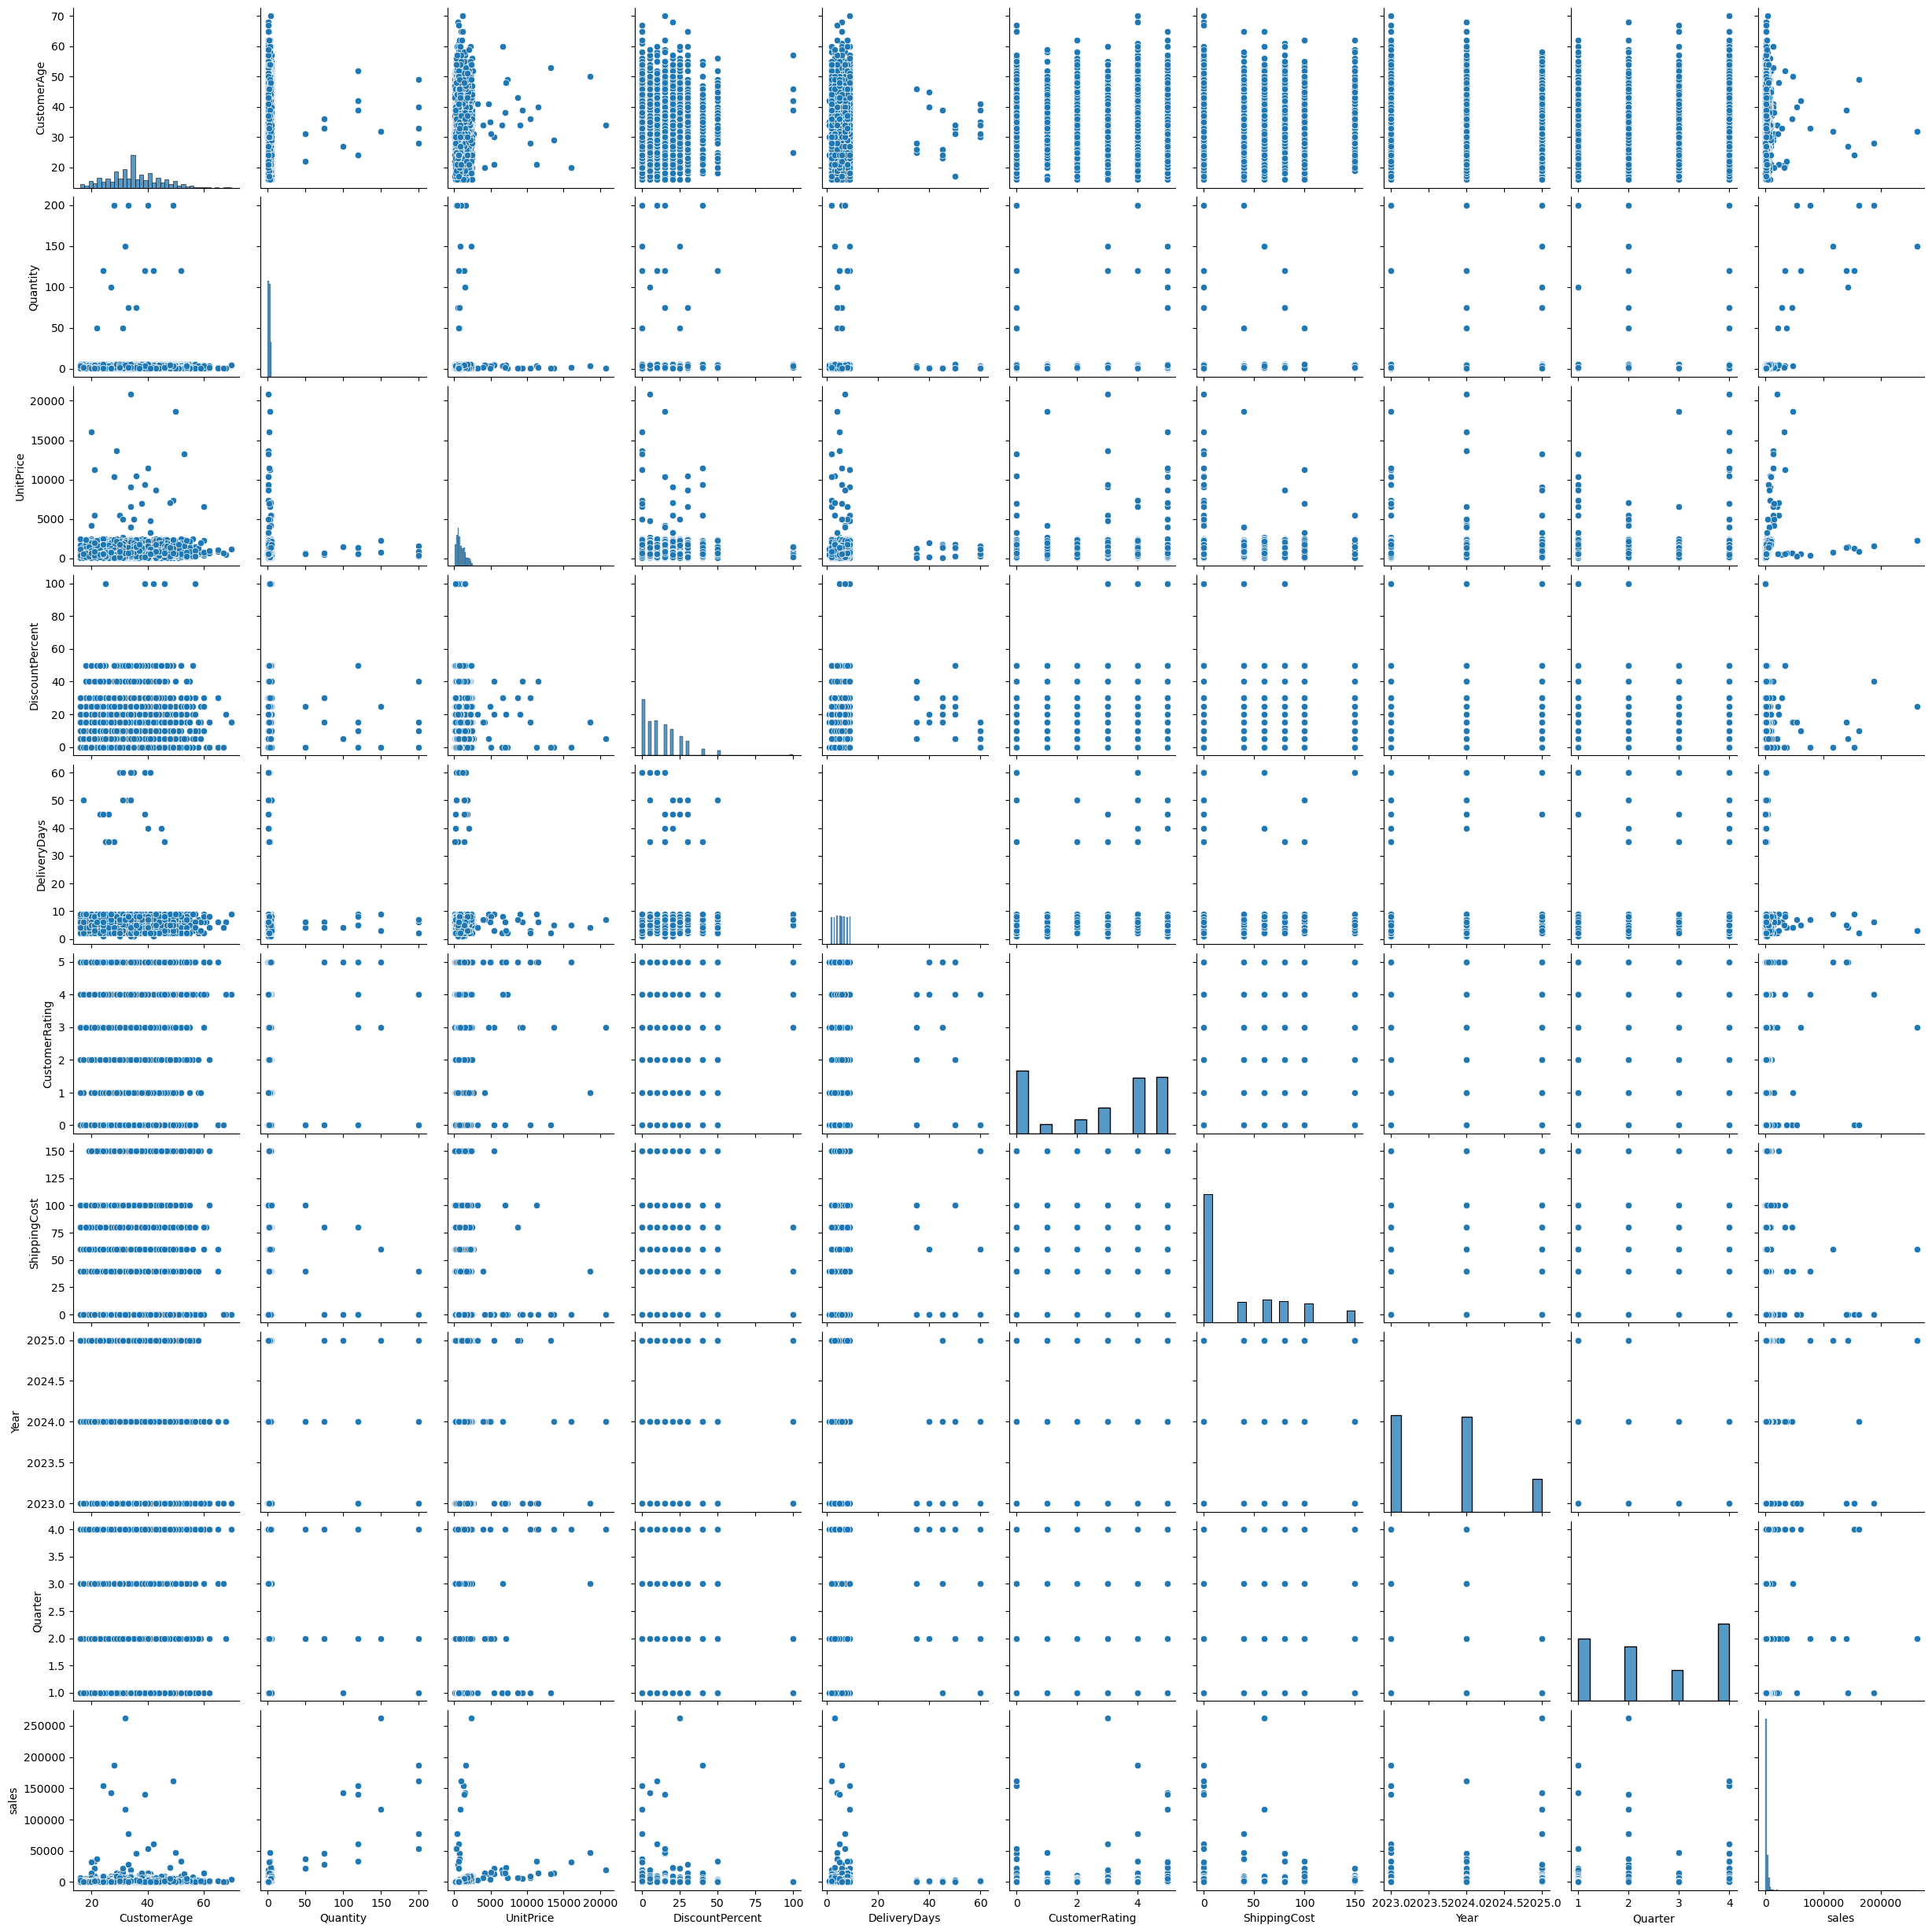

In [91]:
sns.pairplot(df)

<Axes: xlabel='Gender', ylabel='count'>

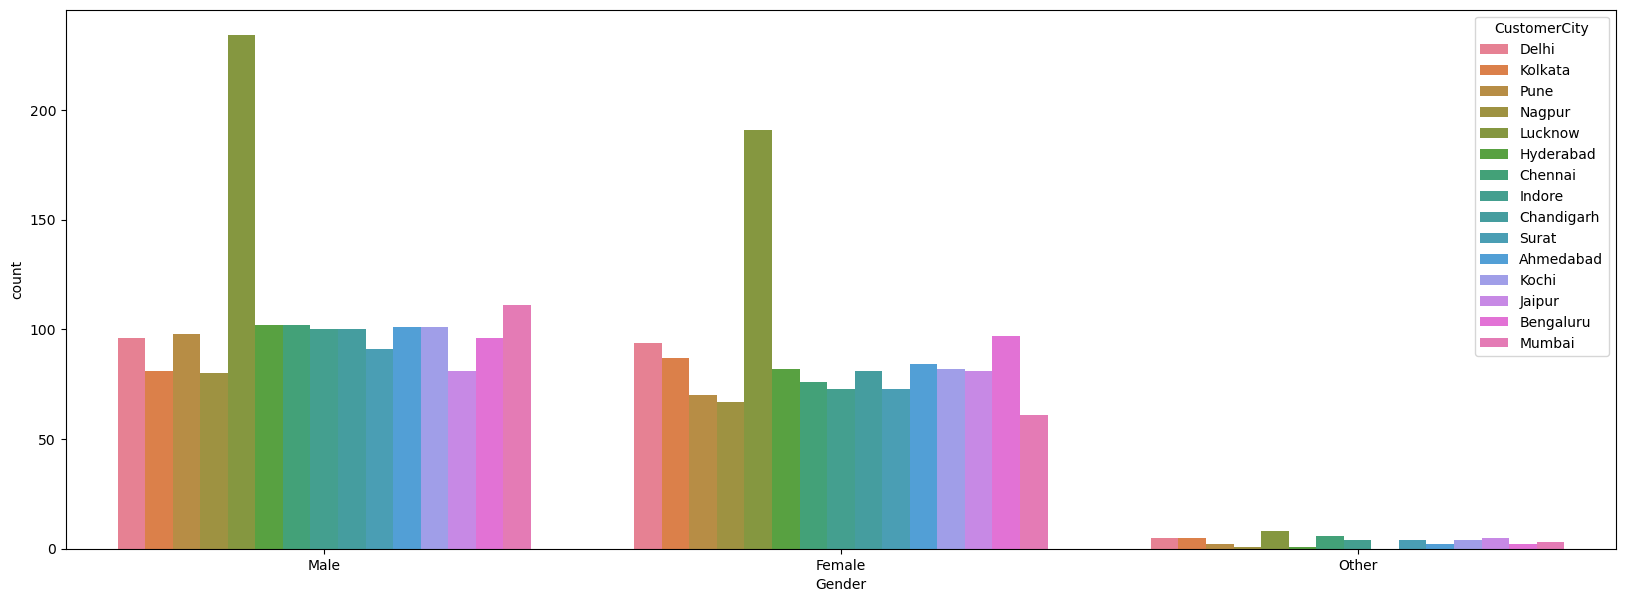

In [92]:
plt.figure(figsize = (20,7))
sns.countplot(x= df['Gender'],hue= df['CustomerCity'])


In [93]:
# both gender are equally distributedd among all cities

<Axes: xlabel='PaymentMethod', ylabel='count'>

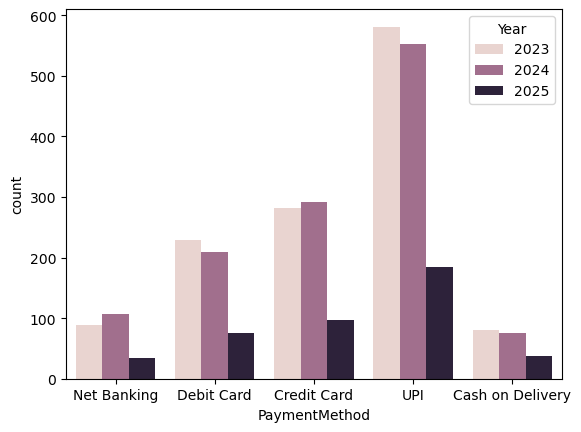

In [94]:
sns.countplot(x=df['PaymentMethod'],hue = df['Year'])

In [95]:
# in 2024 most of the payment were done by net banking

In [96]:
# in 2023 most of the payment done by debit card,upi,cod

<Axes: xlabel='Gender', ylabel='count'>

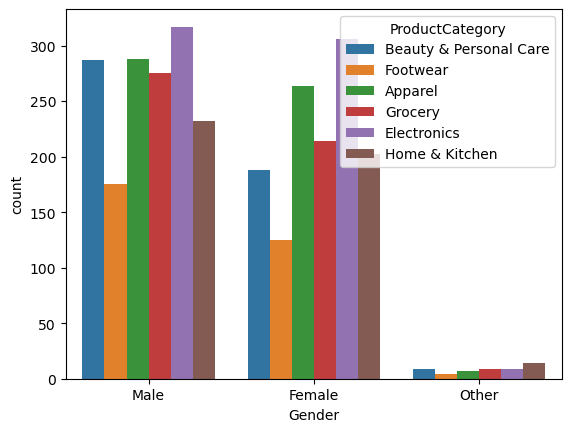

In [97]:
sns.countplot(x=df['Gender'],hue = df['ProductCategory'])

# outliers

In [98]:
df.head()

,OrderID,OrderDate,CustomerName,CustomerAge,Gender,CustomerCity,ProductCategory,ProductName,Quantity,UnitPrice,...,CustomerRating,ShippingCost,CouponCode,ReturnReason,Year,Monthname,Dayname,Quarter,sales,QuantityType
0,ORD100674,2024-07-20,Diya Verma,34.0,Male,Delhi,Beauty & Personal Care,Lip Balm Pack,4.0,144.70,...,4.0,0.0,NaN,NaN,2024,July,Saturday,3,578.8000,low
1,ORD102063,2024-10-17,Reyansh Sharma,31.0,Male,Kolkata,Footwear,Formal Leather Shoes,2.0,486.07,...,0.0,0.0,NEWUSER15,NaN,2024,October,Thursday,4,583.2840,low
2,ORD100377,2024-11-11,Sara Deshmukh,51.0,Male,Pune,Apparel,Men Cotton T-Shirt,1.0,852.46,...,4.0,0.0,FEST20,NaN,2024,November,Monday,4,767.2140,low
3,ORD100802,2024-04-14,Riya Kapoor,49.0,Male,Nagpur,Apparel,Men Cotton T-Shirt,1.0,1246.09,...,0.0,0.0,NEWUSER15,NaN,2024,April,Sunday,2,1246.0900,low
4,ORD101208,2023-09-17,Sneha Pillai,39.0,Male,Lucknow,Grocery,Green Tea Pack,1.0,379.31,...,0.0,80.0,FLAT100,NaN,2023,September,Sunday,3,364.4825,low


<Axes: >

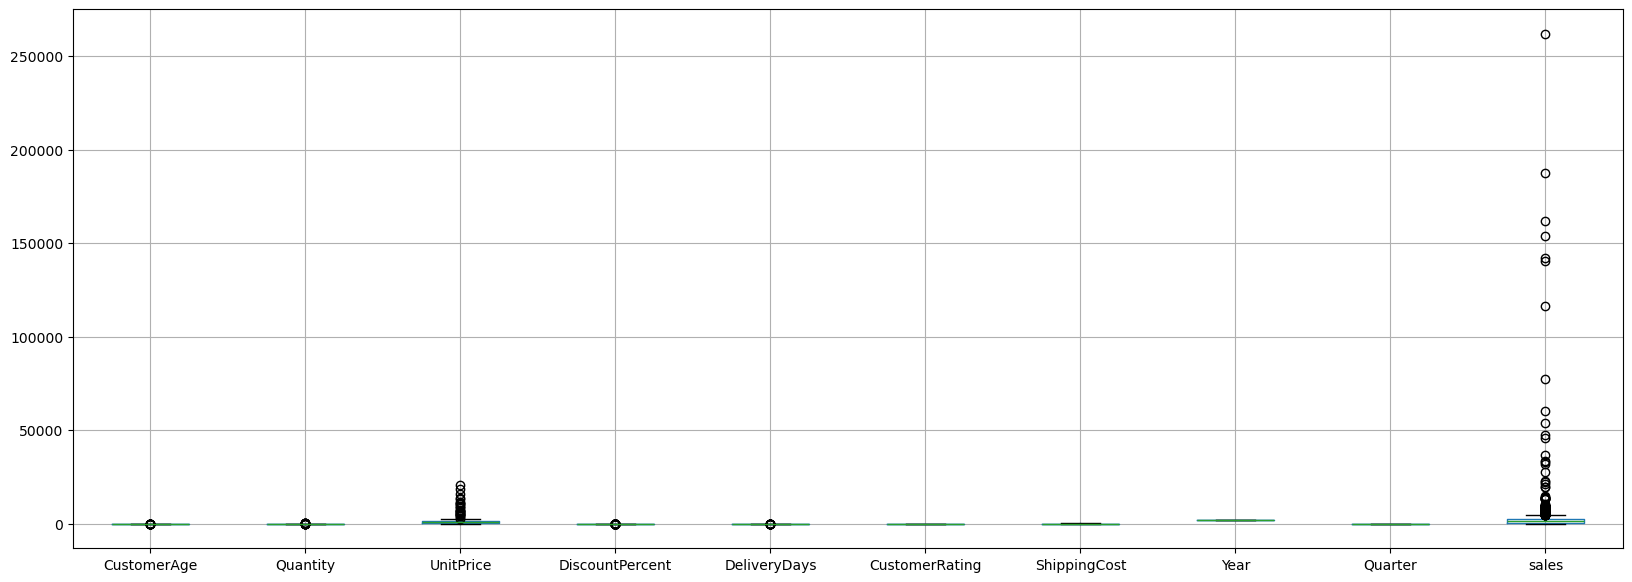

In [99]:
plt.figure(figsize =(20,7))
df.boxplot()

# Dealind with outliers

In [100]:
df.describe()

,OrderDate,CustomerAge,Quantity,UnitPrice,DiscountPercent,DeliveryDays,CustomerRating,ShippingCost,Year,Quarter,sales
count,2925,2925.000000,2925.000000,2925.000000,2925.000000,2925.000000,2925.000000,2925.000000,2925.000000,2925.000000,2925.000000
mean,2024-03-20 20:16:59.076922880,34.609573,2.748376,997.884354,12.994872,5.837265,2.757265,33.856410,2023.715897,2.545299,2359.741422
min,2023-01-01 00:00:00,16.000000,0.000000,80.350000,0.000000,1.000000,0.000000,0.000000,2023.000000,1.000000,0.000000
25%,2023-09-22 00:00:00,29.000000,1.000000,478.610000,5.000000,4.000000,0.000000,0.000000,2023.000000,1.000000,644.592000
50%,2024-02-14 00:00:00,34.000000,2.000000,786.670000,10.000000,5.000000,3.000000,0.000000,2024.000000,2.000000,1236.720000
75%,2024-11-06 00:00:00,40.000000,3.000000,1328.540000,20.000000,8.000000,5.000000,60.000000,2024.000000,4.000000,2309.840000
max,2025-06-29 00:00:00,70.000000,200.000000,20819.867889,100.000000,60.000000,5.000000,150.000000,2025.000000,4.000000,261862.125000
std,NaN,8.952300,9.853663,1030.098789,12.356771,4.552346,1.987621,44.937636,0.704905,1.220163,8937.501977


In [101]:
num_cols = df.select_dtypes([int,float]).columns
num_cols

Index(['CustomerAge', 'Quantity', 'UnitPrice', 'DiscountPercent',
       'DeliveryDays', 'CustomerRating', 'ShippingCost', 'Year', 'Quarter',
       'sales'],
      dtype='object')

num_cols

In [102]:
for i in num_cols:
    q1 = df[i].quantile(0.25)
    q3 = df[i].quantile(0.75)
    iqr = q3 - q1
    lower = q1-(1.5*iqr)
    upper = q3+(1.5*iqr)
    df[i] = df[i].clip(lower,upper)

<Axes: >

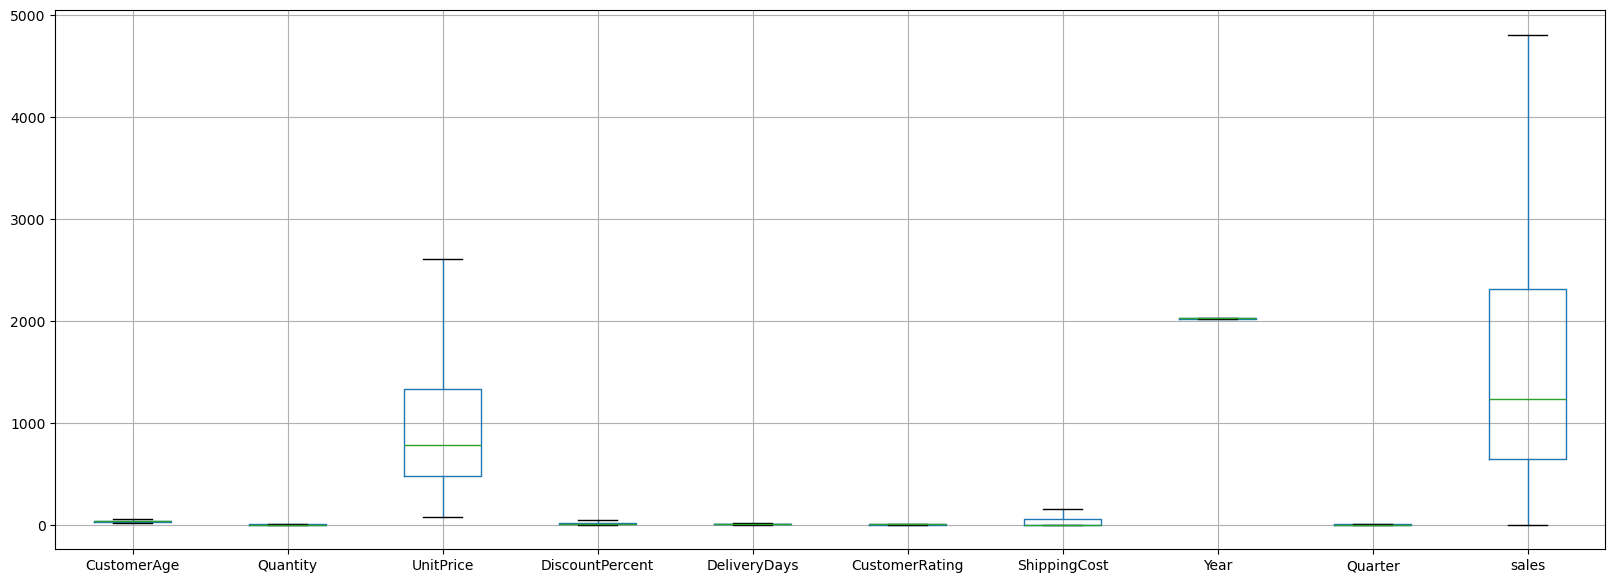

In [103]:
plt.figure(figsize=(20,7))
df.boxplot()

# saving cleaned dataset for further use








In [104]:
df.to_csv('cleaned_sales.csv', index=False)

In [105]:
# End of EDA project


SyntaxError: invalid syntax (2938324653.py, line 1)